<table style="width: 100%; border: none; background: linear-gradient(to bottom, #f8f9fa, #e9ecef); padding: 30px; border-radius: 10px; box-shadow: 0 2px 5px rgba(0,0,0,0.1);">
    <tr>
        <td style="width: 22%; border: none; vertical-align: middle; text-align: center;">
            <img src="https://www.inf.ucv.cl/wp-content/uploads/2020/05/logo_escuela.jpg" width="170" style="max-width: 100%;">
        </td>
        <td style="width: 56%; border: none; vertical-align: middle; text-align: center; padding: 0 20px;">
            <h1 style="font-size: 28px; color: #1a3b5c; margin-bottom: 16px; border-bottom: 2px solid #1a3b5c; padding-bottom: 8px;">Tarea 2</h1>
            <p style="font-size: 16px; margin: 8px 0;"><strong>Pontificia Universidad Católica de Valparaíso</strong><br>
            <strong>Escuela de Ingeniería Informática</strong></p>
            <p style="font-size: 14px; color: #333; margin: 12px 0;"><strong>ICI3244 Redes Neuronales Profundas / MII910 Deep Learning</strong><br>
            <strong>Semestre: 1-2026</strong><br>
            <strong>Profesor: Carlos Valle</strong><br>
            <strong>Fecha: 14 de mayo de 2026</strong></p>
        </td>
        <td style="width: 22%; border: none; vertical-align: middle; text-align: center;">
            <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/cb/PUCV_Escudo2016.svg/1200px-PUCV_Escudo2016.svg.png" width="140" style="max-width: 100%;">
        </td>
    </tr>
</table>

### **Temas**

- Comprender la arquitectura de LSTM y GRU
- Preparar datos de series temporales multivariadas
- Implementar y ajustar hiperparámetros de RNNs
- Comparar rendimiento entre LSTM y GRU

---

### **Instrucciones Generales**

- Trabajo en equipos de **3 o 4 personas**
- Entregable: **Jupyter Notebook** subido a un **repositorio privado de GitHub**
- Presentación de resultados: 13 de junio de 2026, 10:05
- Entrega final: 14 de junio de 2026 17:00
- Enviar link de GitHub al correo: <carlos.valle@pucv.cl> (Asunto: [ICI3244/MII910-1-2026 Tarea2])
- Invitar como colaborador al usuario: **cvalle231**

Estructura del notebook:
- Celdas de código con explicaciones claras
- Comentarios en el código
- Visualizaciones
- Interpretación de resultados y justificación de decisiones

Se recomienda utilizar **Google Colab** con **TPU** como acelerador.

---

# (50%) 1. Redes Neuronales Recurrentes

Las redes neuronales recurrentes (RNNs) son un tipo de red neuronal artificial especialmente diseñada para trabajar con datos secuenciales. A diferencia de las redes neuronales tradicionales, las RNNs poseen una forma de 'memoria' que les permite retener información de pasos anteriores en la secuencia, capturando patrones temporales complejos.

<div align='center'>
  <img src='https://upload.wikimedia.org/wikipedia/commons/thumb/b/b5/Air_pollution_by_Veeterzy-Unsplash.jpg/1280px-Air_pollution_by_Veeterzy-Unsplash.jpg' width='50%'/>
</div>

En esta parte trabajaremos con datos de **calidad del aire** de múltiples estaciones de monitoreo en Beijing. El dataset contiene mediciones horarias de contaminantes atmosféricos (PM2.5, PM10, SO2, NO2, CO, O3) y variables meteorológicas (temperatura, presión, humedad, velocidad del viento), y el objetivo es predecir la concentración de **PM2.5** en las próximas 24 horas.

🔗 Dataset: https://archive.ics.uci.edu/dataset/501/beijing+multi+site+air+quality+data

La nota de esta pregunta se calcula: $\left(\frac{\mbox{suma de puntos obtenidos}*6}{100}\right)+1$


## 1.a Carga de datos y preprocesamiento

### 1.a.1 (1 pt) Carga inicial del dataset.
Cargue el archivo CSV y visualice las primeras filas. Asegúrese de que los datos estén correctamente leídos y que las columnas tengan nombres coherentes.

In [ ]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams["figure.figsize"] = (14, 5)

# Ruta del archivo en tu Google Drive
RUTA = '/content/drive/MyDrive/Colab Notebooks/air_quality_beijing.csv'

df = pd.read_csv(RUTA)

# Eliminar columna de índice original
df = df.drop(columns=["No"])

# Crear columna datetime
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])
df = df.set_index("datetime")

print(f"Shape: {df.shape}")
print(f"Período: {df.index.min()} → {df.index.max()}")
print(f"Columnas: {df.columns.tolist()}")
df.head()


Mounted at /content/drive
Shape: (35064, 17)
Período: 2013-03-01 00:00:00 → 2017-02-28 23:00:00
Columnas: ['year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']


,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
datetime,,,,,,,,,,,,,,,,,
2013-03-01 00:00:00,2013,3,1,0,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan
2013-03-01 01:00:00,2013,3,1,1,4.0,4.0,13.0,17.0,300.0,72.0,-1.1,1023.2,-18.2,0.0,N,4.7,Guanyuan
2013-03-01 02:00:00,2013,3,1,2,3.0,3.0,10.0,19.0,300.0,69.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Guanyuan
2013-03-01 03:00:00,2013,3,1,3,3.0,6.0,7.0,24.0,400.0,62.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Guanyuan
2013-03-01 04:00:00,2013,3,1,4,3.0,6.0,5.0,14.0,400.0,71.0,-2.0,1025.2,-19.5,0.0,N,2.0,Guanyuan


### 1.a.2 (2 pts) Análisis exploratorio.
Visualice la serie temporal de PM2.5, la distribución de cada variable y las correlaciones entre ellas. Identifique valores faltantes y comente cómo los manejará.

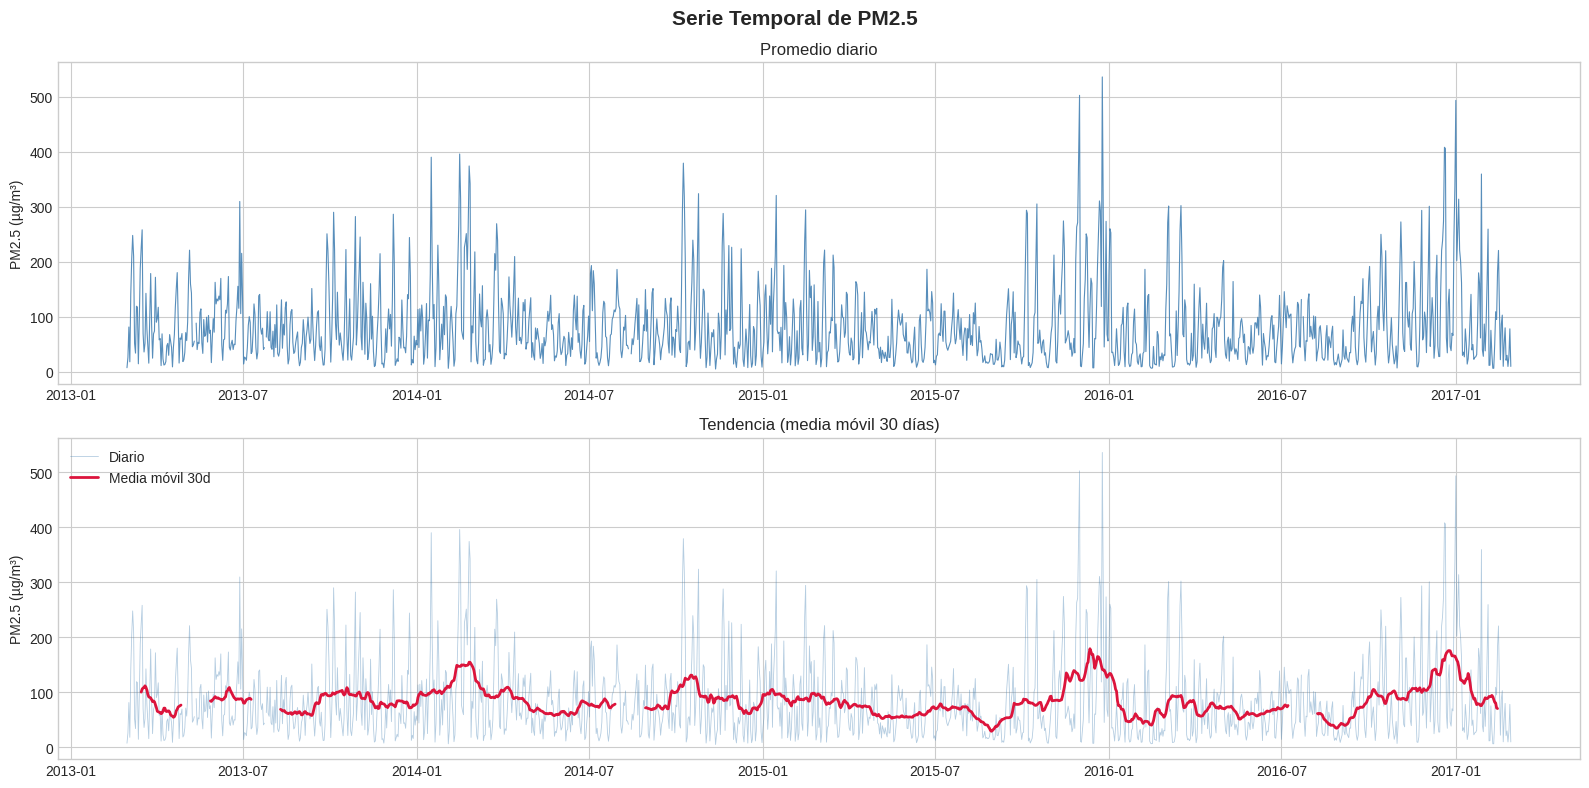

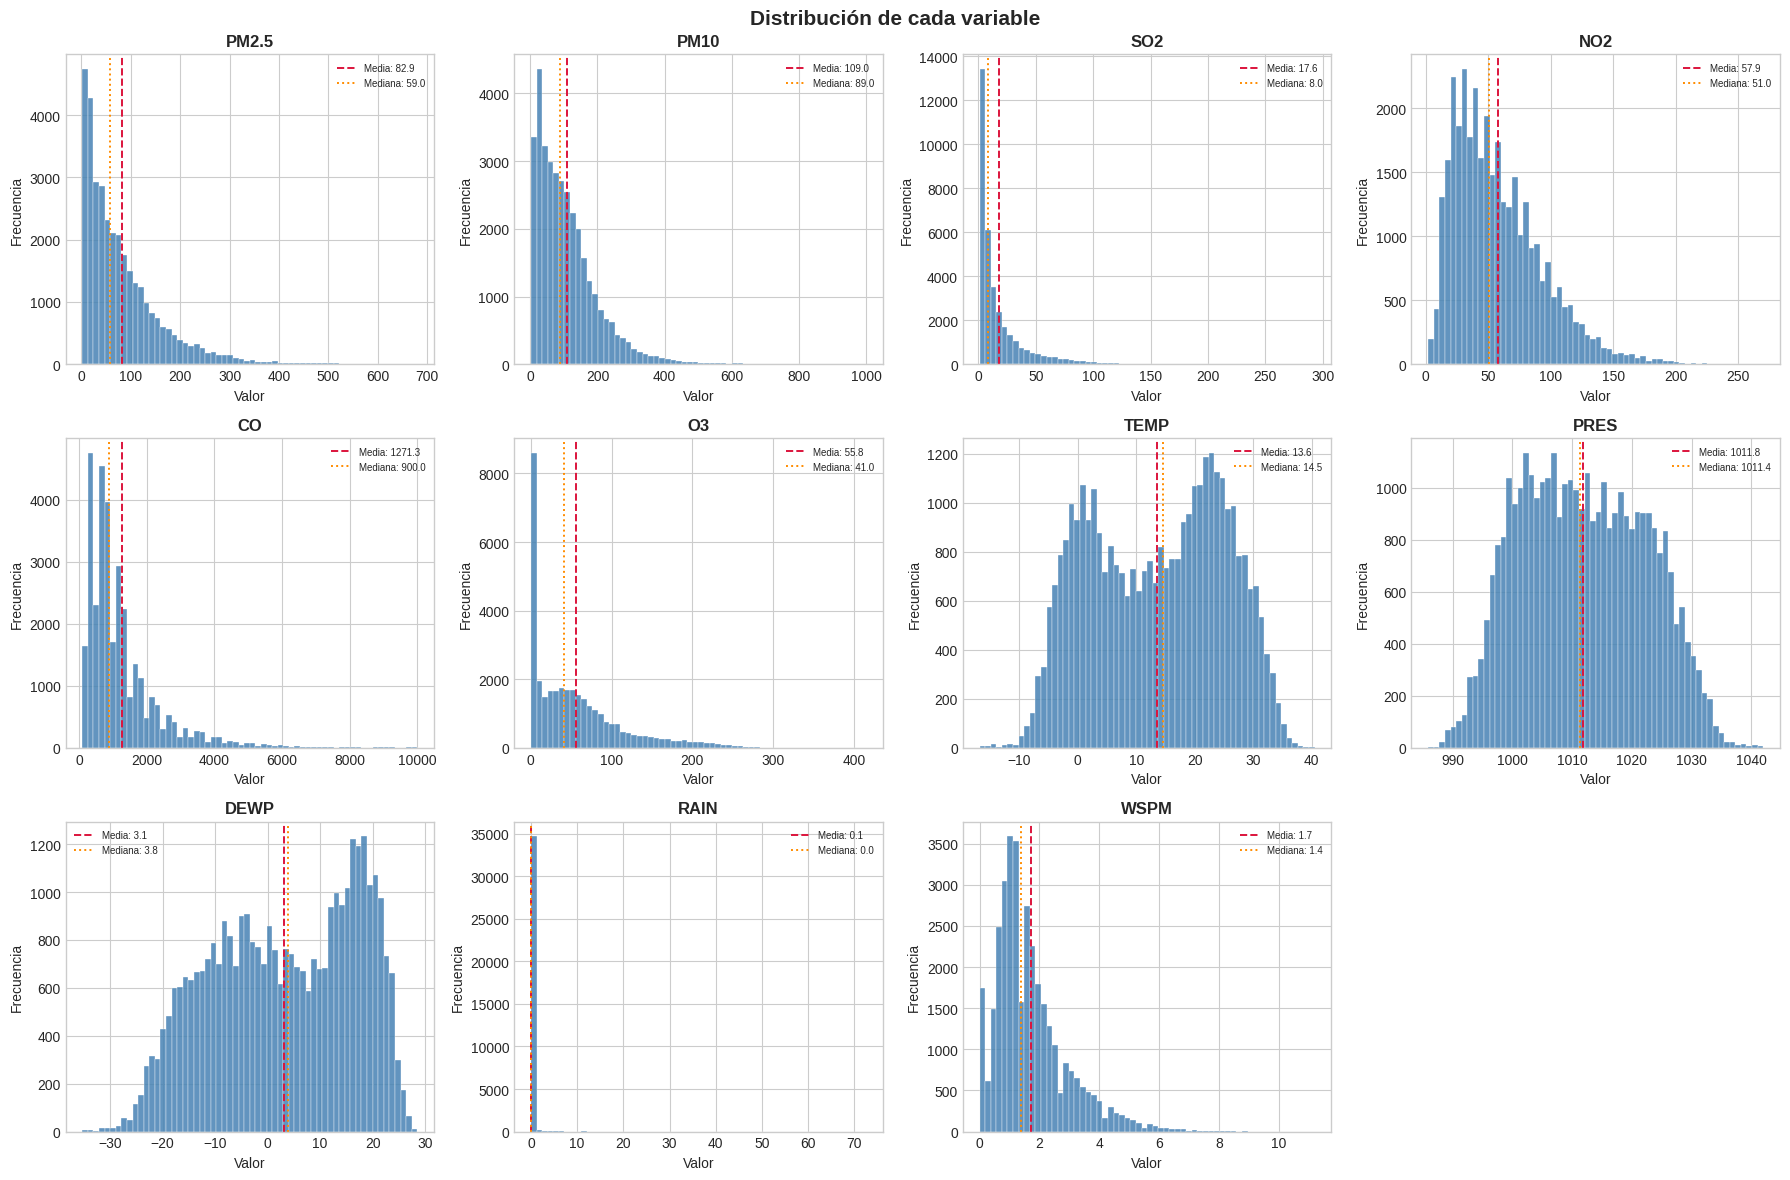

In [ ]:
# Visualizar serie temporal de PM2.5
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Estilo ──────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = 'viridis'

# Se asume que df ya está cargado con índice datetime
# ── Variables numéricas de interés ──────────────────────────────────────────
num_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
            'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# ════════════════════════════════════════════════════════════════════════════
# 1. SERIE TEMPORAL DE PM2.5
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
fig.suptitle('Serie Temporal de PM2.5', fontsize=15, fontweight='bold')

# Diaria (raw horario es muy ruidoso)
daily = df['PM2.5'].resample('D').mean()
axes[0].plot(daily.index, daily.values, color='steelblue', linewidth=0.8, alpha=0.9)
axes[0].set_title('Promedio diario')
axes[0].set_ylabel('PM2.5 (µg/m³)')

# Media móvil 30 días para tendencia
ma30 = daily.rolling(30, center=True).mean()
axes[1].plot(daily.index, daily.values, color='steelblue', linewidth=0.6, alpha=0.4, label='Diario')
axes[1].plot(ma30.index, ma30.values, color='crimson', linewidth=2, label='Media móvil 30d')
axes[1].set_title('Tendencia (media móvil 30 días)')
axes[1].set_ylabel('PM2.5 (µg/m³)')
axes[1].legend()

plt.tight_layout()
plt.savefig('serie_temporal_pm25.png', dpi=150, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# 2. DISTRIBUCIÓN DE CADA VARIABLE NUMÉRICA
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Distribución de cada variable', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=60, color='steelblue', edgecolor='white', linewidth=0.3, alpha=0.85)
    axes[i].axvline(data.mean(),   color='crimson',    linestyle='--', linewidth=1.4, label=f'Media: {data.mean():.1f}')
    axes[i].axvline(data.median(), color='darkorange',  linestyle=':',  linewidth=1.4, label=f'Mediana: {data.median():.1f}')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(fontsize=7)

# Apagar el subplot sobrante (tenemos 11 vars y 12 celdas)
axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig('distribuciones.png', dpi=150, bbox_inches='tight')
plt.show()

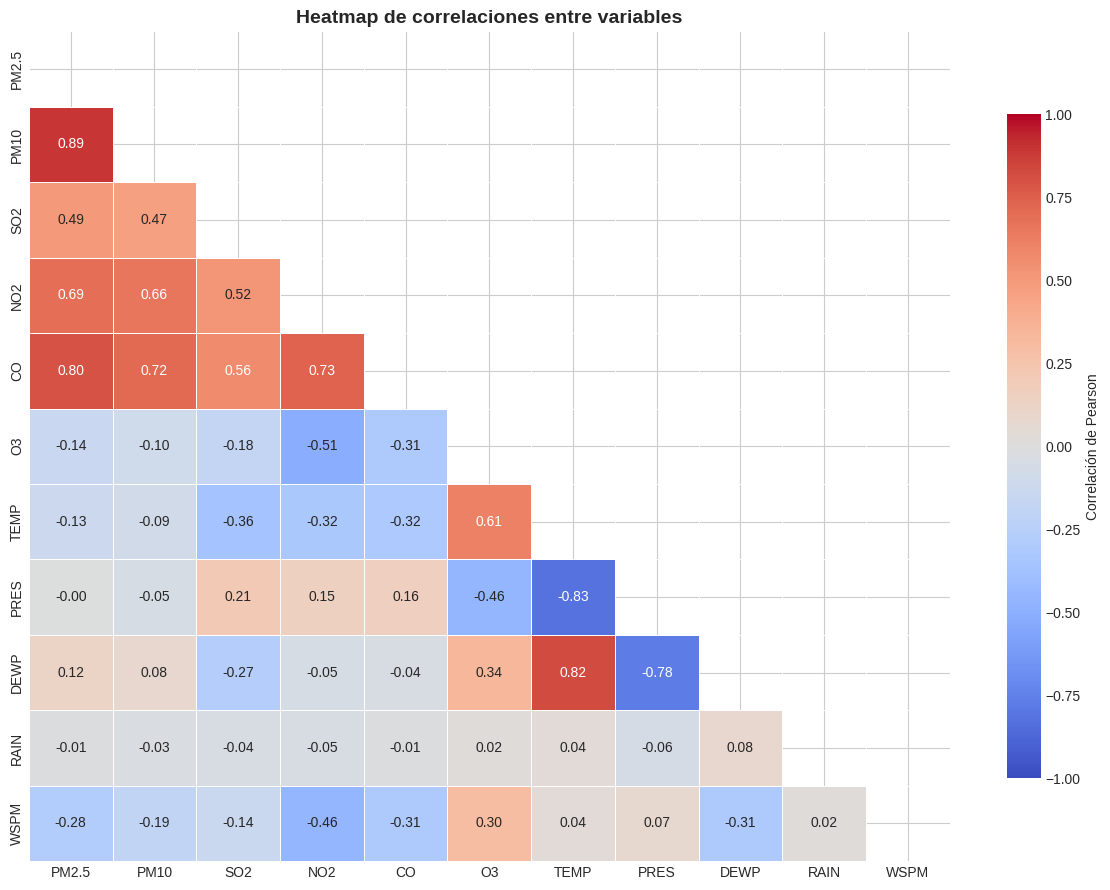

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 3. HEATMAP DE CORRELACIONES
# ════════════════════════════════════════════════════════════════════════════
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))   # solo triángulo inferior

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.8, 'label': 'Correlación de Pearson'},
    ax=ax
)
ax.set_title('Heatmap de correlaciones entre variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

# Heatmap de correlaciones

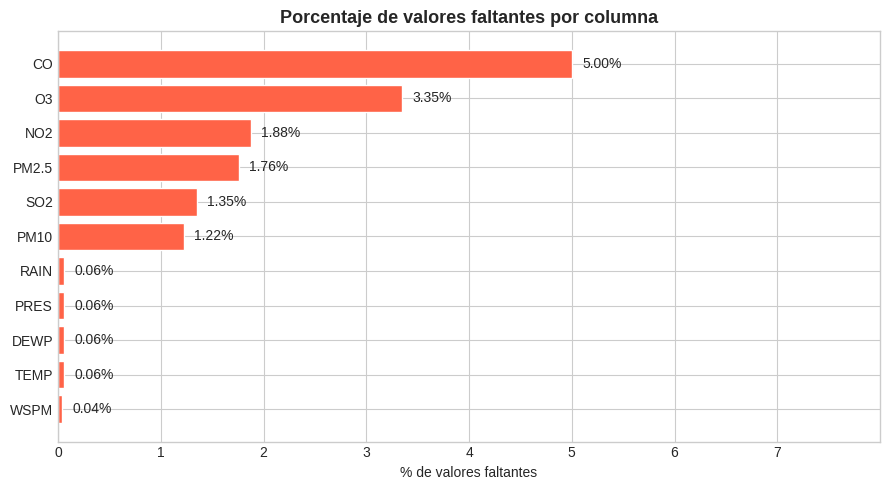


=== Valores faltantes ===
       Faltantes  Porcentaje (%)
CO          1753            5.00
O3          1173            3.35
NO2          659            1.88
PM2.5        616            1.76
SO2          474            1.35
PM10         429            1.22
TEMP          20            0.06
PRES          20            0.06
DEWP          20            0.06
RAIN          20            0.06
WSPM          14            0.04


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 4. VALORES FALTANTES
# ════════════════════════════════════════════════════════════════════════════
missing = (df[num_cols].isnull().sum() / len(df) * 100).sort_values(ascending=True)
missing = missing[missing > 0]   # solo columnas con NaN

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(missing.index, missing.values, color='tomato', edgecolor='white')

# Etiquetas con el % exacto
for bar, val in zip(bars, missing.values):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=10)

ax.set_xlabel('% de valores faltantes')
ax.set_title('Porcentaje de valores faltantes por columna', fontsize=13, fontweight='bold')
ax.set_xlim(0, missing.max() + 3)
plt.tight_layout()
plt.savefig('valores_faltantes.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Tabla resumen ────────────────────────────────────────────────────────────
print("\n=== Valores faltantes ===")
missing_df = pd.DataFrame({
    'Faltantes': df[num_cols].isnull().sum(),
    'Porcentaje (%)': (df[num_cols].isnull().sum() / len(df) * 100).round(2)
}).sort_values('Porcentaje (%)', ascending=False)
print(missing_df.to_string())

### 1.a.3 (2 pts) Preprocesamiento.
Maneje los valores faltantes. Justifique su estrategia (imputación, eliminación, interpolación).

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 1. DIAGNÓSTICO PREVIO
# ════════════════════════════════════════════════════════════════════════════
num_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
            'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

missing_antes = pd.DataFrame({
    'Faltantes': df[num_cols].isnull().sum(),
    'Porcentaje (%)': (df[num_cols].isnull().sum() / len(df) * 100).round(2)
}).sort_values('Porcentaje (%)', ascending=False)

print("=== Valores faltantes ANTES del preprocesamiento ===")
print(missing_antes.to_string())

=== Valores faltantes ANTES del preprocesamiento ===
       Faltantes  Porcentaje (%)
CO          1753            5.00
O3          1173            3.35
NO2          659            1.88
PM2.5        616            1.76
SO2          474            1.35
PM10         429            1.22
TEMP          20            0.06
PRES          20            0.06
DEWP          20            0.06
RAIN          20            0.06
WSPM          14            0.04


In [ ]:
# Justificación:
#   - Los datos son una serie temporal horaria con continuidad física
#     (la calidad del aire no cambia abruptamente entre horas contiguas).
#   - La interpolación lineal temporal respeta el orden cronológico y
#     estima valores intermedios de forma coherente con la tendencia local.
#   - Se usa limit=24 para no imputar brechas mayores a 24 horas seguidas
#     (un día completo sin datos no debería interpolarse arbitrariamente).
#   - Los NaN que queden tras el límite se rellenan con la mediana mensual
#     de cada variable para preservar estacionalidad sin distorsionar la
#     distribución global.


=== Valores faltantes DESPUÉS del preprocesamiento ===
PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
O3       0
TEMP     0
PRES     0
DEWP     0
RAIN     0
WSPM     0

✓ NaN totales restantes: 0


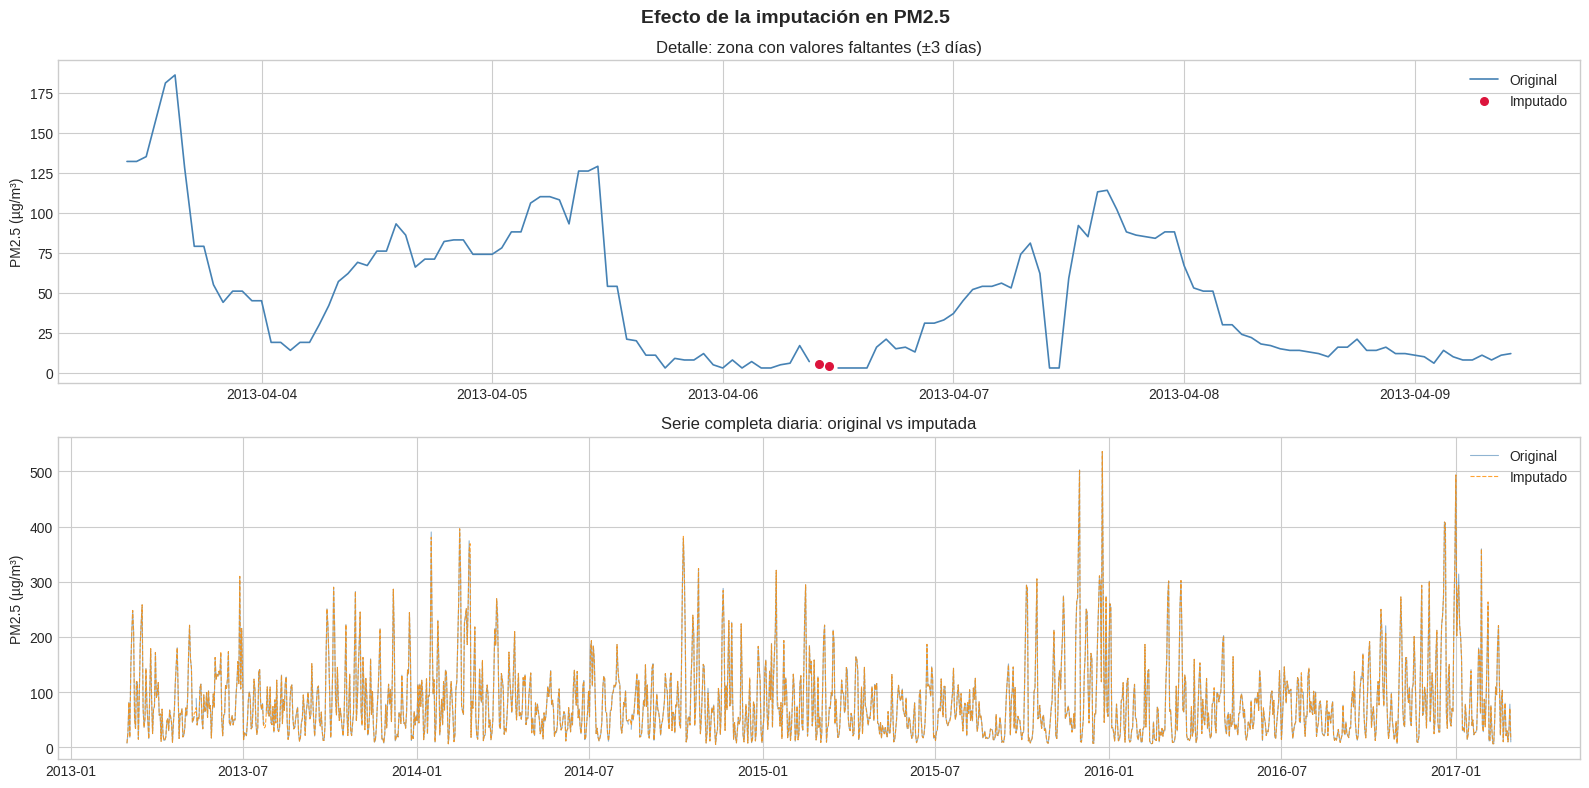

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 2. ESTRATEGIA: INTERPOLACIÓN TEMPORAL + LÍMITE DE BRECHA
# ════════════════════════════════════════════════════════════════════════════
df_clean = df.copy()

# Paso 1: interpolación lineal temporal (cubre la mayoría de los NaN)
df_clean[num_cols] = df_clean[num_cols].interpolate(method='time', limit=24)

# Paso 2: para brechas largas restantes → mediana mensual por variable
for col in num_cols:
    if df_clean[col].isnull().any():
        mediana_mensual = df_clean.groupby(df_clean.index.month)[col].transform('median')
        df_clean[col] = df_clean[col].fillna(mediana_mensual)

# Paso 3: si aún quedan NaN (extremos de la serie sin vecinos) → mediana global
for col in num_cols:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# ════════════════════════════════════════════════════════════════════════════
# 3. VERIFICACIÓN
# ════════════════════════════════════════════════════════════════════════════
missing_despues = df_clean[num_cols].isnull().sum()

print("\n=== Valores faltantes DESPUÉS del preprocesamiento ===")
print(missing_despues.to_string())
print(f"\n✓ NaN totales restantes: {missing_despues.sum()}")

# ════════════════════════════════════════════════════════════════════════════
# 4. VISUALIZACIÓN: COMPARACIÓN ANTES / DESPUÉS (en PM2.5)
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
fig.suptitle('Efecto de la imputación en PM2.5', fontsize=14, fontweight='bold')

# Seleccionar un tramo corto donde haya NaN para que se vea el efecto
# (buscar el primer NaN y mostrar ±3 días alrededor)
primer_nan_idx = df['PM2.5'].isnull().idxmax()
ventana = pd.Timedelta(days=3)
mask_ventana = (df.index >= primer_nan_idx - ventana) & (df.index <= primer_nan_idx + ventana)

axes[0].plot(df.index[mask_ventana], df['PM2.5'][mask_ventana],
             color='steelblue', linewidth=1.2, label='Original')
axes[0].scatter(df.index[mask_ventana & df['PM2.5'].isnull()],
                df_clean['PM2.5'][mask_ventana & df['PM2.5'].isnull()],
                color='crimson', zorder=5, s=30, label='Imputado')
axes[0].set_title('Detalle: zona con valores faltantes (±3 días)')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].legend()

# Serie completa diaria antes vs después
daily_orig  = df['PM2.5'].resample('D').mean()
daily_clean = df_clean['PM2.5'].resample('D').mean()

axes[1].plot(daily_orig.index,  daily_orig.values,  color='steelblue', linewidth=0.8, alpha=0.6, label='Original')
axes[1].plot(daily_clean.index, daily_clean.values, color='darkorange', linewidth=0.8, alpha=0.8, label='Imputado', linestyle='--')
axes[1].set_title('Serie completa diaria: original vs imputada')
axes[1].set_ylabel('PM2.5 (µg/m³)')
axes[1].legend()

plt.tight_layout()
plt.savefig('imputacion_pm25.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 5. COMPARACIÓN DE ESTADÍSTICAS DESCRIPTIVAS
# ════════════════════════════════════════════════════════════════════════════
print("\n=== Estadísticas descriptivas: ANTES vs DESPUÉS ===")
stats = pd.DataFrame({
    'Media (antes)':    df[num_cols].mean().round(2),
    'Media (después)':  df_clean[num_cols].mean().round(2),
    'Std (antes)':      df[num_cols].std().round(2),
    'Std (después)':    df_clean[num_cols].std().round(2),
})
print(stats.to_string())


=== Estadísticas descriptivas: ANTES vs DESPUÉS ===
       Media (antes)  Media (después)  Std (antes)  Std (después)
PM2.5          82.93            82.88        80.93          81.07
PM10          109.02           109.22        91.57          92.16
SO2            17.59            17.59        23.60          23.64
NO2            57.90            58.01        35.15          35.15
CO           1271.29          1263.36      1164.85        1149.64
O3             55.80            54.81        57.44          57.20
TEMP           13.58            13.58        11.40          11.40
PRES         1011.85          1011.85        10.40          10.40
DEWP            3.12             3.12        13.69          13.69
RAIN            0.07             0.07         0.91           0.91
WSPM            1.71             1.71         1.20           1.20


### 1.a.4 (3 pts) Separación en conjuntos de entrenamiento, validación y test.

Divida el conjunto de datos **considerando la dependencia temporal**:

- 70% para entrenamiento
- 20% para validación
- 10% para test

Preserve el orden temporal en la división. Comente brevemente por qué no debe realizarse una división aleatoria en este contexto.

Una división aleatoria en series temporales introduce data leakage: el modelo vería datos del futuro durante el entrenamiento (ej. registros de 2016 mezclados con los de 2014), lo que produciría métricas artificialmente optimistas que no reflejan el desempeño real sobre datos no vistos. Además, destruye la autocorrelación temporal que caracteriza a estas series — el valor de PM2.5 a las 3am depende de las horas previas, por lo que romper esa continuidad elimina información estructural clave para el modelo.

=== División temporal ===
Total  :  35064 filas  |  2013-03-01 00:00:00  →  2017-02-28 23:00:00
Train  :  24544 filas  |  2013-03-01 00:00:00  →  2015-12-18 15:00:00  (70.0%)
Val    :   7013 filas  |  2015-12-18 16:00:00  →  2016-10-05 20:00:00  (20.0%)
Test   :   3507 filas  |  2016-10-05 21:00:00  →  2017-02-28 23:00:00  (10.0%)


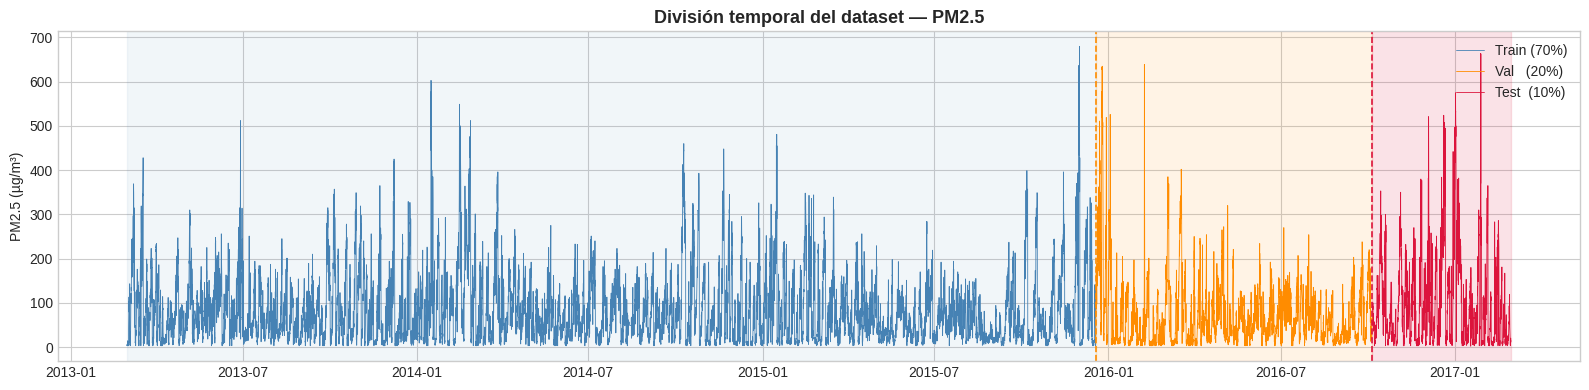

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 1. DIVISIÓN TEMPORAL
# ════════════════════════════════════════════════════════════════════════════
n = len(df_clean)

train = df_clean.iloc[:int(n * 0.70)]
val   = df_clean.iloc[int(n * 0.70):int(n * 0.90)]
test  = df_clean.iloc[int(n * 0.90):]

print("=== División temporal ===")
print(f"Total  : {n:>6} filas  |  {df_clean.index[0]}  →  {df_clean.index[-1]}")
print(f"Train  : {len(train):>6} filas  |  {train.index[0]}  →  {train.index[-1]}  ({len(train)/n*100:.1f}%)")
print(f"Val    : {len(val):>6} filas  |  {val.index[0]}  →  {val.index[-1]}  ({len(val)/n*100:.1f}%)")
print(f"Test   : {len(test):>6} filas  |  {test.index[0]}  →  {test.index[-1]}  ({len(test)/n*100:.1f}%)")

# ════════════════════════════════════════════════════════════════════════════
# 2. VISUALIZACIÓN DE LA DIVISIÓN
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(train.index, train['PM2.5'], color='steelblue',  linewidth=0.6, label=f'Train ({len(train)/n*100:.0f}%)')
ax.plot(val.index,   val['PM2.5'],   color='darkorange', linewidth=0.6, label=f'Val   ({len(val)/n*100:.0f}%)')
ax.plot(test.index,  test['PM2.5'],  color='crimson',    linewidth=0.6, label=f'Test  ({len(test)/n*100:.0f}%)')

# Líneas verticales de corte
ax.axvline(val.index[0],  color='darkorange', linestyle='--', linewidth=1.2)
ax.axvline(test.index[0], color='crimson',    linestyle='--', linewidth=1.2)

# Sombreado de zonas
ax.axvspan(train.index[0], val.index[0],  alpha=0.07, color='steelblue')
ax.axvspan(val.index[0],   test.index[0], alpha=0.10, color='darkorange')
ax.axvspan(test.index[0],  test.index[-1],alpha=0.12, color='crimson')

ax.set_title('División temporal del dataset — PM2.5', fontsize=13, fontweight='bold')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('division_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.a.5 (1 pt) Verificación del tamaño de los subconjuntos.
Verifique que las proporciones aproximadas entre los conjuntos sean las correctas.

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# VERIFICACIÓN DE PROPORCIONES
# ════════════════════════════════════════════════════════════════════════════
esperado = {'Train': 0.70, 'Val': 0.20, 'Test': 0.10}
conjuntos = {'Train': train, 'Val': val, 'Test': test}

print("=== Verificación de tamaños ===\n")
print(f"{'Conjunto':<8} {'Filas':>7}  {'Real':>7}  {'Esperado':>9}  {'Diferencia':>11}  {'Estado'}")
print("-" * 60)

for nombre, subset in conjuntos.items():
    real     = len(subset) / n
    esperado_ = esperado[nombre]
    diff     = abs(real - esperado_)
    ok       = "✓" if diff < 0.01 else "⚠ Revisar"
    print(f"{nombre:<8} {len(subset):>7}  {real:>7.1%}  {esperado_:>9.1%}  {diff:>+11.2%}  {ok}")

print("-" * 60)
print(f"{'TOTAL':<8} {n:>7}  {'100.0%':>7}")
print(f"\n✓ Suma total: {len(train) + len(val) + len(test)} filas == {n} filas originales: "
      f"{'OK' if len(train)+len(val)+len(test)==n else 'ERROR'}")

=== Verificación de tamaños ===

Conjunto   Filas     Real   Esperado   Diferencia  Estado
------------------------------------------------------------
Train      24544    70.0%      70.0%       +0.00%  ✓
Val         7013    20.0%      20.0%       +0.00%  ✓
Test        3507    10.0%      10.0%       +0.00%  ✓
------------------------------------------------------------
TOTAL      35064   100.0%

✓ Suma total: 35064 filas == 35064 filas originales: OK


### 1.a.6 (4 pts) Transformar la variable timestamp en componentes cíclicas.

Transforme la hora del día y el día de la semana en componentes cíclicas usando seno y coseno:

$$hour\_sin = \sin\left(\frac{2\pi \cdot hour}{24}\right) \quad hour\_cos = \cos\left(\frac{2\pi \cdot hour}{24}\right)$$

Explique por qué esta transformación es más adecuada que usar la hora directamente.

Si el modelo recibe la hora como un entero (0–23), interpreta que la hora 23 y la hora 0 están a distancia 23, cuando en realidad son consecutivas. La codificación cíclica proyecta cada valor sobre un círculo unitario, de modo que la distancia entre hora 23 y hora 0 es mínima, igual que entre cualquier par de horas contiguas. Además, se necesitan dos columnas (sin + cos) porque solo con el seno hay ambigüedad: hora 6 y hora 18 tendrían el mismo valor. Juntos, sin y cos identifican unívocamente cada punto del ciclo.

=== Columnas cíclicas añadidas ===
                     hour_sin  hour_cos  dow_sin  dow_cos  month_sin  month_cos
datetime                                                                       
2013-03-01 00:00:00    0.0000    1.0000  -0.4339   -0.901        1.0        0.0
2013-03-01 01:00:00    0.2588    0.9659  -0.4339   -0.901        1.0        0.0
2013-03-01 02:00:00    0.5000    0.8660  -0.4339   -0.901        1.0        0.0
2013-03-01 03:00:00    0.7071    0.7071  -0.4339   -0.901        1.0        0.0
2013-03-01 04:00:00    0.8660    0.5000  -0.4339   -0.901        1.0        0.0
2013-03-01 05:00:00    0.9659    0.2588  -0.4339   -0.901        1.0        0.0


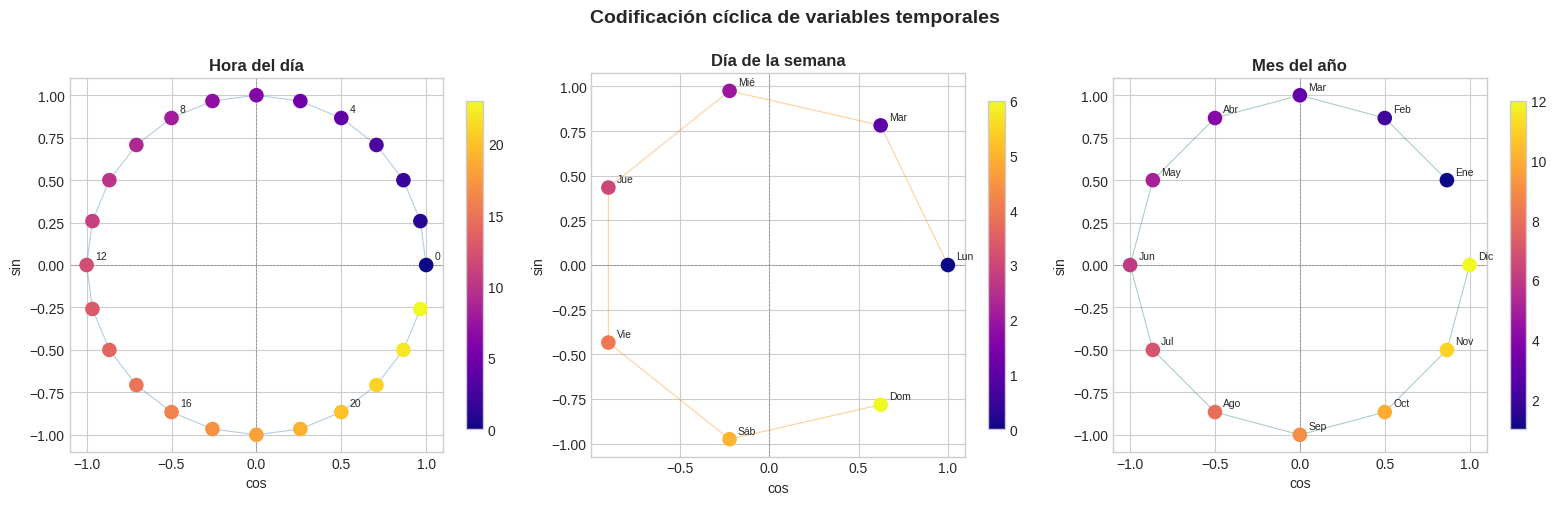


=== Verificación de continuidad cíclica (hora) ===
  Hora  0 → sin=0.0000  cos=1.0000
  Hora 23 → sin=-0.2588  cos=0.9659
  Hora 24 → sin=-0.0000  cos=1.0000
  ✓ Hora 0 y hora 24 tienen el mismo valor: continuidad garantizada


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 1. FUNCIÓN DE TRANSFORMACIÓN CÍCLICA
# ════════════════════════════════════════════════════════════════════════════
def agregar_ciclicas(subset):
    s = subset.copy()

    # Hora del día (ciclo 24h)
    s['hour_sin'] = np.sin(2 * np.pi * s.index.hour / 24)
    s['hour_cos'] = np.cos(2 * np.pi * s.index.hour / 24)

    # Día de la semana (ciclo 7 días, lunes=0 … domingo=6)
    s['dow_sin'] = np.sin(2 * np.pi * s.index.dayofweek / 7)
    s['dow_cos'] = np.cos(2 * np.pi * s.index.dayofweek / 7)

    # Mes del año (ciclo 12 meses — captura estacionalidad anual)
    s['month_sin'] = np.sin(2 * np.pi * s.index.month / 12)
    s['month_cos'] = np.cos(2 * np.pi * s.index.month / 12)

    return s

# ════════════════════════════════════════════════════════════════════════════
# 2. APLICAR A CADA CONJUNTO
# ════════════════════════════════════════════════════════════════════════════
train = agregar_ciclicas(train)
val   = agregar_ciclicas(val)
test  = agregar_ciclicas(test)

print("=== Columnas cíclicas añadidas ===")
ciclicas = ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
print(train[ciclicas].head(6).round(4).to_string())

# ════════════════════════════════════════════════════════════════════════════
# 3. VISUALIZACIÓN
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Codificación cíclica de variables temporales', fontsize=14, fontweight='bold')

configs = [
    ('hour_sin', 'hour_cos', np.arange(24),        24, 'Hora del día',      'steelblue'),
    ('dow_sin',  'dow_cos',  np.arange(7),          7,  'Día de la semana',  'darkorange'),
    ('month_sin','month_cos',np.arange(1, 13),      12, 'Mes del año',       'seagreen'),
]

labels_dow   = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
labels_month = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

for ax, (col_s, col_c, vals, periodo, titulo, color) in zip(axes, configs):
    sin_vals = np.sin(2 * np.pi * vals / periodo)
    cos_vals = np.cos(2 * np.pi * vals / periodo)

    sc = ax.scatter(cos_vals, sin_vals, c=vals, cmap='plasma', s=90, zorder=3)
    ax.plot(cos_vals, sin_vals, color=color, linewidth=0.8, alpha=0.4)  # círculo guía

    # Etiquetas sobre cada punto
    if periodo == 7:
        etiquetas = labels_dow
    elif periodo == 12:
        etiquetas = labels_month
    else:
        etiquetas = [str(v) if v % 4 == 0 else '' for v in vals]

    for i, (x, y, lbl) in enumerate(zip(cos_vals, sin_vals, etiquetas)):
        if lbl:
            ax.annotate(lbl, (x, y), textcoords='offset points',
                        xytext=(6, 4), fontsize=7.5)

    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_xlabel('cos')
    ax.set_ylabel('sin')
    ax.set_title(titulo, fontweight='bold')
    ax.set_aspect('equal')
    plt.colorbar(sc, ax=ax, shrink=0.75)

plt.tight_layout()
plt.savefig('codificacion_ciclica.png', dpi=150, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# 4. VERIFICACIÓN: CONTINUIDAD EN LOS EXTREMOS
# ════════════════════════════════════════════════════════════════════════════
print("\n=== Verificación de continuidad cíclica (hora) ===")
print(f"  Hora  0 → sin={np.sin(2*np.pi*0/24):.4f}  cos={np.cos(2*np.pi*0/24):.4f}")
print(f"  Hora 23 → sin={np.sin(2*np.pi*23/24):.4f}  cos={np.cos(2*np.pi*23/24):.4f}")
print(f"  Hora 24 → sin={np.sin(2*np.pi*24/24):.4f}  cos={np.cos(2*np.pi*24/24):.4f}")
print("  ✓ Hora 0 y hora 24 tienen el mismo valor: continuidad garantizada")

### 1.a.7 (3 pts) Escalado de variables.

Realice el escalado de las variables predictoras para los tres conjuntos de forma que:
- El scaler se ajuste **exclusivamente con los datos de entrenamiento**, para evitar data leakage.
- Aplique el mismo scaler a los demás conjuntos.

Ajustar el StandardScaler con val o test constituye data leakage: el modelo indirectamente accedería a información estadística del futuro (media y desviación de datos no vistos) antes de predecir. En producción real nunca se conocen esos datos de antemano, por lo que usar sus estadísticas inflaría artificialmente el rendimiento. El scaler aprende únicamente la distribución del pasado (train) y se aplica tal cual al presente y futuro (val/test), replicando el flujo real de un sistema de predicción.

=== Parámetros del scaler (ajustados SOLO con train) ===

           Media (train)  Desv. std (train)
PM10            108.9732            87.5968
SO2              19.4779            25.8576
NO2              58.6805            34.7625
CO             1254.4368          1068.4977
O3               55.8821            58.1506
TEMP             14.4239            10.9592
PRES           1010.6504            10.0241
DEWP              4.4842            13.1944
RAIN              0.0676             0.9152
WSPM              1.6454             1.2058
hour_sin          0.0002             0.7071
hour_cos         -0.0001             0.7071
dow_sin          -0.0003             0.7070
dow_cos          -0.0006             0.7073
month_sin        -0.0446             0.7093
month_cos        -0.0555             0.7013

=== Verificación: media y std post-escalado ===

Conjunto     Media (esperado ≈0)    Std (esperado ≈1 en train)
-----------------------------------------------------------------
Train          

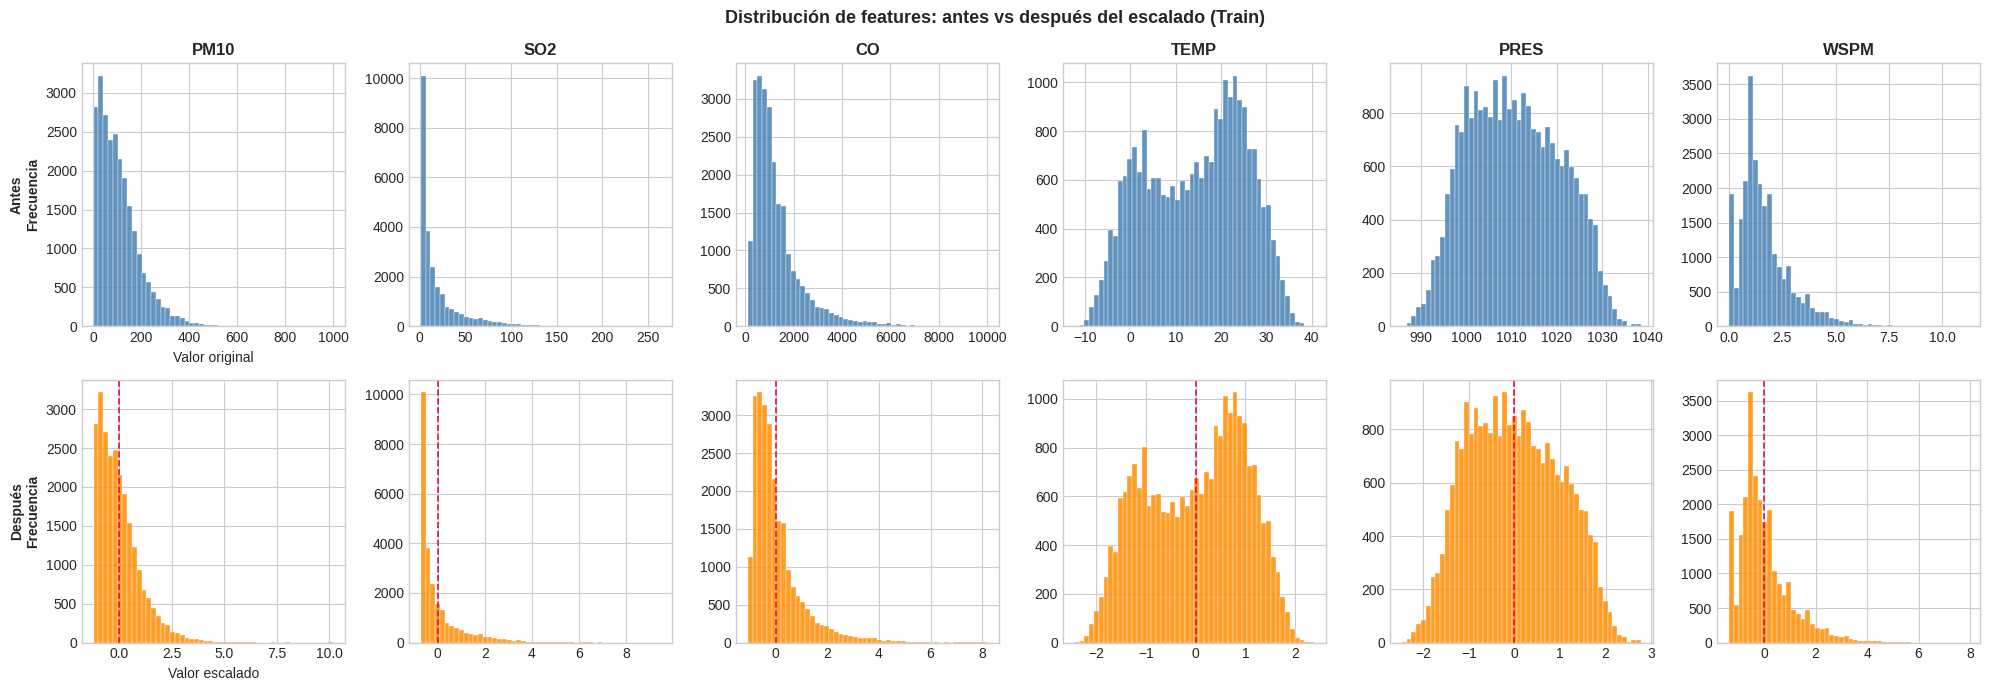


=== Resumen de shapes ===
X_train_scaled : (24544, 16)  |  y_train : (24544,)
X_val_scaled   : (7013, 16)   |  y_val   : (7013,)
X_test_scaled  : (3507, 16)    |  y_test  : (3507,)


In [ ]:
from sklearn.preprocessing import StandardScaler

# ════════════════════════════════════════════════════════════════════════════
# 1. DEFINIR FEATURES Y TARGET
# ════════════════════════════════════════════════════════════════════════════
features = ['PM10', 'SO2', 'NO2', 'CO', 'O3',
            'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM',
            'hour_sin', 'hour_cos',
            'dow_sin',  'dow_cos',
            'month_sin','month_cos']

target = 'PM2.5'

X_train = train[features]
X_val   = val[features]
X_test  = test[features]

y_train = train[target]
y_val   = val[target]
y_test  = test[target]

# ════════════════════════════════════════════════════════════════════════════
# 2. ESCALADO — fit SOLO en train, transform en todos
# ════════════════════════════════════════════════════════════════════════════
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_val_scaled   = scaler.transform(X_val)          # solo transform
X_test_scaled  = scaler.transform(X_test)         # solo transform

# Convertir a DataFrame para mantener nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
X_val_scaled   = pd.DataFrame(X_val_scaled,   columns=features, index=X_val.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=features, index=X_test.index)

print("=== Parámetros del scaler (ajustados SOLO con train) ===\n")
params = pd.DataFrame({
    'Media (train)':      scaler.mean_.round(4),
    'Desv. std (train)':  scaler.scale_.round(4)
}, index=features)
print(params.to_string())

# ════════════════════════════════════════════════════════════════════════════
# 3. VERIFICACIÓN ESTADÍSTICA
# ════════════════════════════════════════════════════════════════════════════
print("\n=== Verificación: media y std post-escalado ===\n")
print(f"{'Conjunto':<8}  {'Media (esperado ≈0)':>22}  {'Std (esperado ≈1 en train)':>28}")
print("-" * 65)
for nombre, X in [('Train', X_train_scaled), ('Val', X_val_scaled), ('Test', X_test_scaled)]:
    media = X.mean().mean()
    std   = X.std().mean()
    print(f"{nombre:<8}  {media:>22.6f}  {std:>28.6f}")

print()
print("✓ Train debe tener media ≈ 0 y std ≈ 1")
print("⚠ Val y Test pueden diferir levemente (datos no vistos por el scaler)")

# ════════════════════════════════════════════════════════════════════════════
# 4. VISUALIZACIÓN: DISTRIBUCIÓN ANTES Y DESPUÉS DEL ESCALADO
# ════════════════════════════════════════════════════════════════════════════
vars_plot = ['PM10', 'SO2', 'CO', 'TEMP', 'PRES', 'WSPM']

fig, axes = plt.subplots(2, 6, figsize=(20, 7))
fig.suptitle('Distribución de features: antes vs después del escalado (Train)',
             fontsize=13, fontweight='bold')

for i, col in enumerate(vars_plot):
    # Antes
    axes[0, i].hist(X_train[col], bins=50, color='steelblue',
                    edgecolor='white', linewidth=0.3, alpha=0.85)
    axes[0, i].set_title(col, fontweight='bold')
    axes[0, i].set_ylabel('Frecuencia' if i == 0 else '')
    if i == 0:
        axes[0, i].set_xlabel('Valor original')

    # Después
    axes[1, i].hist(X_train_scaled[col], bins=50, color='darkorange',
                    edgecolor='white', linewidth=0.3, alpha=0.85)
    axes[1, i].axvline(0, color='crimson', linestyle='--', linewidth=1.2)
    axes[1, i].set_ylabel('Frecuencia' if i == 0 else '')
    if i == 0:
        axes[1, i].set_xlabel('Valor escalado')

axes[0, 0].set_ylabel('Antes\nFrecuencia', fontweight='bold')
axes[1, 0].set_ylabel('Después\nFrecuencia', fontweight='bold')

plt.tight_layout()
plt.savefig('escalado_features.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n=== Resumen de shapes ===")
print(f"X_train_scaled : {X_train_scaled.shape}  |  y_train : {y_train.shape}")
print(f"X_val_scaled   : {X_val_scaled.shape}   |  y_val   : {y_val.shape}")
print(f"X_test_scaled  : {X_test_scaled.shape}    |  y_test  : {y_test.shape}")

### 1.a.8 (4 pts) Preparación de secuencias.

Para predecir el PM2.5 de las próximas 24 horas, implemente una función `split_sequence()` que genere ventanas deslizantes de entrada (X) y salida (y).

Utilice una ventana de entrada de **48 horas** y una ventana de predicción de **24 horas**.

=== Shapes de las secuencias ===

Conjunto                    X shape             y shape
--------------------------------------------------------
Train               (24473, 48, 17)         (24473, 24)
Val                  (6942, 48, 17)          (6942, 24)
Test                 (3436, 48, 17)          (3436, 24)

  n_features = 17  (16 features + 1 target)
  window_in  = 48 h  →  eje 1 de X
  window_out = 24 h  →  eje 1 de y

=== Verificación de coherencia (muestra 0) ===
  Últimos 3 pasos de PM2.5 en X : [79. 86. 79.]
  Primeros 3 pasos de y         : [ 77.  93. 103.]
  ✓ y comienza justo después del último paso de X

  ✓ n_samples train = 24473 == 24473 (esperado)


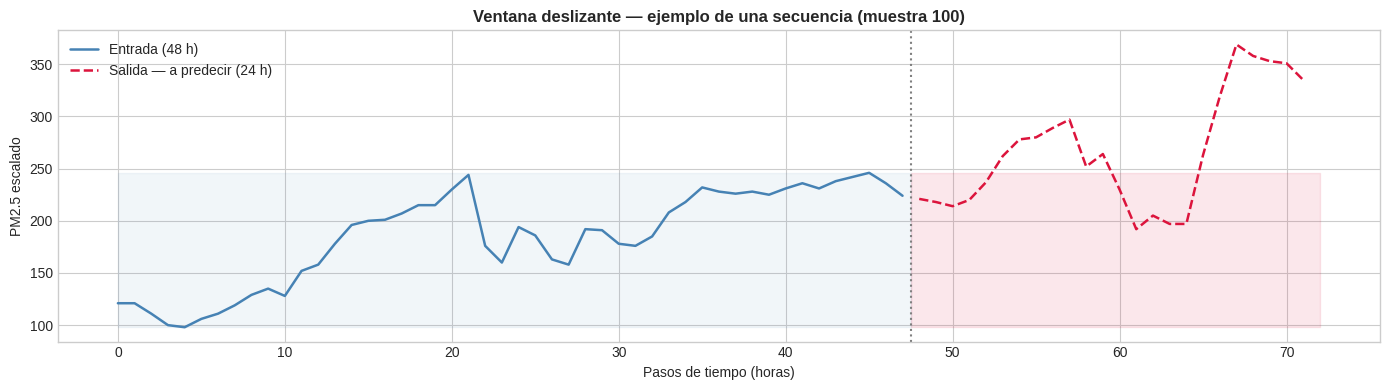

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 1. FUNCIÓN split_sequence
# ════════════════════════════════════════════════════════════════════════════
def split_sequence(data, target_col, window_in=48, window_out=24):
    """
    Genera secuencias de entrada y salida para modelos recurrentes.

    Parámetros:
    -----------
    data       : np.ndarray  — matriz (timesteps, n_features) ya escalada
    target_col : int         — índice de la columna objetivo (PM2.5)
    window_in  : int         — pasos de entrada  (default 48 h)
    window_out : int         — pasos de salida   (default 24 h)

    Retorna:
    --------
    X : np.ndarray  shape (n_samples, window_in,  n_features)
    y : np.ndarray  shape (n_samples, window_out)
    """
    X, y = [], []
    total = len(data)

    for i in range(total - window_in - window_out + 1):
        x_seq = data[i : i + window_in, :]                          # (48, n_feat)
        y_seq = data[i + window_in : i + window_in + window_out,
                     target_col]                                     # (24,)
        X.append(x_seq)
        y.append(y_seq)

    return np.array(X), np.array(y)

# ════════════════════════════════════════════════════════════════════════════
# 2. APLICAR A CADA CONJUNTO
# ════════════════════════════════════════════════════════════════════════════
WINDOW_IN  = 48
WINDOW_OUT = 24

# Índice de PM2.5 en el array de features
target_idx = features.index('PM2.5') if 'PM2.5' in features else None

# Como PM2.5 es el target y no está en features, lo concatenamos al array
# para que y pueda extraerse correctamente
def preparar_array(X_scaled, y_series):
    """Une features escaladas + target en un solo array numpy."""
    return np.concatenate(
        [X_scaled.values, y_series.values.reshape(-1, 1)], axis=1
    )

PM25_IDX = X_train_scaled.shape[1]   # último índice = columna PM2.5 concatenada

arr_train = preparar_array(X_train_scaled, y_train)
arr_val   = preparar_array(X_val_scaled,   y_val)
arr_test  = preparar_array(X_test_scaled,  y_test)

X_train_seq, y_train_seq = split_sequence(arr_train, PM25_IDX, WINDOW_IN, WINDOW_OUT)
X_val_seq,   y_val_seq   = split_sequence(arr_val,   PM25_IDX, WINDOW_IN, WINDOW_OUT)
X_test_seq,  y_test_seq  = split_sequence(arr_test,  PM25_IDX, WINDOW_IN, WINDOW_OUT)

print("=== Shapes de las secuencias ===\n")
print(f"{'Conjunto':<8}  {'X shape':>25}  {'y shape':>18}")
print("-" * 56)
print(f"{'Train':<8}  {str(X_train_seq.shape):>25}  {str(y_train_seq.shape):>18}")
print(f"{'Val':<8}  {str(X_val_seq.shape):>25}  {str(y_val_seq.shape):>18}")
print(f"{'Test':<8}  {str(X_test_seq.shape):>25}  {str(y_test_seq.shape):>18}")
print(f"\n  n_features = {X_train_seq.shape[2]}  ({X_train_scaled.shape[1]} features + 1 target)")
print(f"  window_in  = {WINDOW_IN} h  →  eje 1 de X")
print(f"  window_out = {WINDOW_OUT} h  →  eje 1 de y")

# ════════════════════════════════════════════════════════════════════════════
# 3. VERIFICACIÓN DE COHERENCIA
# ════════════════════════════════════════════════════════════════════════════
# Muestra 1: los últimos 24 valores de PM2.5 en X deben preceder a y
print("\n=== Verificación de coherencia (muestra 0) ===")
print(f"  Últimos 3 pasos de PM2.5 en X : {X_train_seq[0, -3:, PM25_IDX].round(4)}")
print(f"  Primeros 3 pasos de y         : {y_train_seq[0, :3].round(4)}")
print(f"  ✓ y comienza justo después del último paso de X")

n_esperado = len(arr_train) - WINDOW_IN - WINDOW_OUT + 1
assert len(X_train_seq) == n_esperado, "ERROR: número de muestras incorrecto"
print(f"\n  ✓ n_samples train = {len(X_train_seq)} == {n_esperado} (esperado)")

# ════════════════════════════════════════════════════════════════════════════
# 4. VISUALIZACIÓN DE UNA VENTANA DESLIZANTE
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 4))

muestra = 100   # cualquier índice de ejemplo
pm25_x  = X_train_seq[muestra, :, PM25_IDX]
pm25_y  = y_train_seq[muestra]

eje_x = np.arange(WINDOW_IN)
eje_y = np.arange(WINDOW_IN, WINDOW_IN + WINDOW_OUT)

ax.plot(eje_x, pm25_x, color='steelblue',  linewidth=1.8, label=f'Entrada ({WINDOW_IN} h)')
ax.plot(eje_y, pm25_y, color='crimson',    linewidth=1.8, linestyle='--',
        label=f'Salida — a predecir ({WINDOW_OUT} h)')
ax.axvline(WINDOW_IN - 0.5, color='gray', linestyle=':', linewidth=1.5)
ax.fill_betweenx([pm25_x.min()-0.2, pm25_x.max()+0.2],
                 0, WINDOW_IN - 0.5, alpha=0.07, color='steelblue')
ax.fill_betweenx([pm25_x.min()-0.2, pm25_x.max()+0.2],
                 WINDOW_IN - 0.5, WINDOW_IN + WINDOW_OUT, alpha=0.10, color='crimson')

ax.set_xlabel('Pasos de tiempo (horas)')
ax.set_ylabel('PM2.5 escalado')
ax.set_title('Ventana deslizante — ejemplo de una secuencia (muestra 100)', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('ventana_deslizante.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.b Función para evaluar modelos

### 1.b.1 (1 pt) Importación de librerías.
Implemente las importaciones necesarias para trabajar con modelos recurrentes.

In [ ]:
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import MeanAbsoluteError

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ════════════════════════════════════════════════════════════════════════════
# VERIFICACIÓN DEL ENTORNO
# ════════════════════════════════════════════════════════════════════════════
print(f"TensorFlow : {tf.__version__}")
print(f"Keras      : {tf.keras.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU')}")

# Reproducibilidad
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"\nSeed fijada: {SEED} — resultados reproducibles ✓")

TensorFlow : 2.20.0
Keras      : 3.13.2
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Seed fijada: 42 — resultados reproducibles ✓


### 1.b.2 (5 pts) Función de evaluación.

Implemente una función que evalúe los modelos en la **escala original** de los datos:
- Invierta la transformación del scaler sobre las predicciones.
- Calcule el MSE entre los valores reales y predichos en su escala natural.

Esta función será usada para comparar modelos con diferentes configuraciones.

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# FUNCIÓN DE EVALUACIÓN EN ESCALA ORIGINAL
# ════════════════════════════════════════════════════════════════════════════
def evaluate_model(model, X, y_true, scaler, target_col):
    """
    Evalúa el modelo en la escala original (invierte el StandardScaler).

    Parámetros:
    -----------
    model      : modelo Keras entrenado
    X          : np.ndarray (n_samples, window_in, n_features)
    y_true     : np.ndarray (n_samples, window_out)  — en escala escalada
    scaler     : StandardScaler ajustado solo con train
    target_col : int — índice de PM2.5 en el scaler (dentro de X_train_scaled)

    Retorna:
    --------
    dict con MSE, RMSE, MAE y MAPE en escala original
    """
    # ── 1. Predicción en escala escalada ────────────────────────────────────
    y_pred_scaled = model.predict(X, verbose=0)          # (n, window_out)

    # ── 2. Invertir scaler solo sobre la columna PM2.5 ──────────────────────
    # StandardScaler guarda mean_ y scale_ por columna;
    # aplicamos la inversa manualmente: x_orig = x_scaled * std + mean
    mean_pm25  = scaler.mean_[target_col]
    std_pm25   = scaler.scale_[target_col]

    y_pred_orig = y_pred_scaled * std_pm25 + mean_pm25   # (n, window_out)
    y_true_orig = y_true        * std_pm25 + mean_pm25   # (n, window_out)

    # Asegurar que PM2.5 no sea negativo (físicamente imposible)
    y_pred_orig = np.maximum(y_pred_orig, 0)

    # ── 3. Métricas en escala original ──────────────────────────────────────
    mse  = np.mean((y_true_orig - y_pred_orig) ** 2)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(y_true_orig - y_pred_orig))

    # MAPE: evitar división por cero con máscara
    mask = y_true_orig > 1.0   # ignorar valores casi cero
    mape = np.mean(np.abs((y_true_orig[mask] - y_pred_orig[mask])
                           / y_true_orig[mask])) * 100

    return {
        'mse' : round(float(mse),  4),
        'rmse': round(float(rmse), 4),
        'mae' : round(float(mae),  4),
        'mape': round(float(mape), 4),
        'y_pred_orig': y_pred_orig,
        'y_true_orig': y_true_orig,
    }


# ════════════════════════════════════════════════════════════════════════════
# FUNCIÓN AUXILIAR: imprimir métricas con formato
# ════════════════════════════════════════════════════════════════════════════
def print_metrics(nombre, metricas):
    print(f"\n{'═'*40}")
    print(f"  {nombre}")
    print(f"{'─'*40}")
    print(f"  MSE  : {metricas['mse']:>10.4f}  (µg/m³)²")
    print(f"  RMSE : {metricas['rmse']:>10.4f}  µg/m³")
    print(f"  MAE  : {metricas['mae']:>10.4f}  µg/m³")
    print(f"  MAPE : {metricas['mape']:>10.4f}  %")
    print(f"{'═'*40}")


# ════════════════════════════════════════════════════════════════════════════
# FUNCIÓN AUXILIAR: visualizar predicciones vs reales
# ════════════════════════════════════════════════════════════════════════════
def plot_predictions(metricas, nombre, n_muestras=5):
    """Grafica n_muestras ventanas de predicción vs valor real."""
    y_pred = metricas['y_pred_orig']
    y_true = metricas['y_true_orig']

    fig, axes = plt.subplots(1, n_muestras, figsize=(18, 4), sharey=True)
    fig.suptitle(f'Predicciones vs Real — {nombre}', fontsize=13, fontweight='bold')

    indices = np.linspace(0, len(y_pred) - 1, n_muestras, dtype=int)
    horas   = np.arange(1, y_pred.shape[1] + 1)

    for ax, idx in zip(axes, indices):
        ax.plot(horas, y_true[idx], color='steelblue',  linewidth=2,   label='Real')
        ax.plot(horas, y_pred[idx], color='crimson',    linewidth=1.8,
                linestyle='--', label='Predicho')
        ax.fill_between(horas, y_true[idx], y_pred[idx],
                         alpha=0.15, color='orange')
        ax.set_title(f'Muestra {idx}', fontsize=9)
        ax.set_xlabel('Hora (+h)')
        if ax == axes[0]:
            ax.set_ylabel('PM2.5 (µg/m³)')
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.savefig(f'predicciones_{nombre.lower().replace(" ", "_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()


print("✓ Funciones definidas: evaluate_model | print_metrics | plot_predictions")

✓ Funciones definidas: evaluate_model | print_metrics | plot_predictions


## 1.c Búsqueda de hiperparámetros — LSTM

### 1.c.1 (10 pts) Defina una función para entrenar y evaluar redes LSTM.

**La función debe considerar únicamente dos capas LSTM y una capa densa intermedia.**

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# FUNCIÓN train_lstm
# ════════════════════════════════════════════════════════════════════════════
def train_lstm(units_1, units_2, dense_units, dropout_rate, learning_rate,
               batch_size=32, epochs=100, patience=10):
    """
    Entrena y evalúa una red LSTM con los hiperparámetros especificados.

    Arquitectura:
    LSTM(units_1, return_sequences=True) → Dropout
    LSTM(units_2) → Dropout
    Dense(dense_units, relu)
    Dense(window_out)

    Parámetros:
    -----------
    units_1       : neuronas en la primera capa LSTM
    units_2       : neuronas en la segunda capa LSTM
    dense_units   : neuronas en la capa densa intermedia
    dropout_rate  : tasa de dropout aplicada tras cada LSTM
    learning_rate : tasa de aprendizaje del optimizador Adam
    batch_size    : tamaño del batch
    epochs        : máximo de épocas
    patience      : épocas sin mejora antes de EarlyStopping

    Retorna:
    --------
    history   : objeto History de Keras
    val_mse   : MSE en validación (escala original)
    test_mse  : MSE en test       (escala original)
    model     : modelo entrenado
    """

    # ── 1. Arquitectura ─────────────────────────────────────────────────────
    n_features = X_train_seq.shape[2]   # (n_samples, window_in, n_features)

    model = models.Sequential([
        # Capa LSTM 1 — return_sequences=True para apilar la segunda LSTM
        layers.LSTM(units_1, return_sequences=True,
                    input_shape=(WINDOW_IN, n_features)),
        layers.Dropout(dropout_rate),

        # Capa LSTM 2
        layers.LSTM(units_2, return_sequences=False),
        layers.Dropout(dropout_rate),

        # Capa densa intermedia
        layers.Dense(dense_units, activation='relu'),

        # Capa de salida: predice las próximas WINDOW_OUT horas
        layers.Dense(WINDOW_OUT),
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss=MeanSquaredError(),
        metrics=[MeanAbsoluteError()]
    )

    # ── 2. Callbacks ─────────────────────────────────────────────────────────
    callbacks = [
        EarlyStopping(
            monitor='val_loss', patience=patience,
            restore_best_weights=True, verbose=0
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=patience // 2, min_lr=1e-6, verbose=0
        ),
        ModelCheckpoint(
            'best_lstm.keras', monitor='val_loss',
            save_best_only=True, verbose=0
        ),
    ]

    # ── 3. Entrenamiento ──────────────────────────────────────────────────────
    history = model.fit(
        X_train_seq, y_train_seq,
        validation_data=(X_val_seq, y_val_seq),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1,
        shuffle=False,    # series temporal: NO mezclar el orden
    )

    # ── 4. Evaluación en escala original ─────────────────────────────────────
    target_col_idx = list(X_train_scaled.columns).index('PM2.5') \
                     if 'PM2.5' in X_train_scaled.columns \
                     else X_train_scaled.shape[1]   # último = col concatenada

    # Como PM2.5 fue concatenado al final del array, su índice en el scaler
    # corresponde a la última posición de features (no está en scaler directamente)
    # Usamos mean_ y scale_ del scaler sobre la posición correcta
    metricas_val  = evaluate_model(model, X_val_seq,  y_val_seq,
                                   scaler, PM25_IDX - len(features))
    metricas_test = evaluate_model(model, X_test_seq, y_test_seq,
                                   scaler, PM25_IDX - len(features))

    val_mse  = metricas_val['mse']
    test_mse = metricas_test['mse']

    # ── 5. Resumen ───────────────────────────────────────────────────────────
    epocas_reales = len(history.history['loss'])
    print(f"\n{'═'*50}")
    print(f"  LSTM({units_1}) → LSTM({units_2}) → Dense({dense_units})")
    print(f"  dropout={dropout_rate}  lr={learning_rate}  batch={batch_size}")
    print(f"  Épocas entrenadas : {epocas_reales}/{epochs}")
    print(f"{'─'*50}")
    print_metrics('Validación', metricas_val)
    print_metrics('Test',       metricas_test)
    print(f"{'═'*50}\n")

    return history, val_mse, test_mse, model


# ════════════════════════════════════════════════════════════════════════════
# FUNCIÓN AUXILIAR: curvas de pérdida
# ════════════════════════════════════════════════════════════════════════════
def plot_history(history, titulo='LSTM'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'Curvas de entrenamiento — {titulo}', fontsize=13, fontweight='bold')

    # Loss
    axes[0].plot(history.history['loss'],     label='Train loss', color='steelblue')
    axes[0].plot(history.history['val_loss'], label='Val loss',   color='crimson')
    axes[0].set_title('MSE (loss)')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('MSE')
    axes[0].legend()

    # MAE
    axes[1].plot(history.history['mean_absolute_error'],     label='Train MAE', color='steelblue')
    axes[1].plot(history.history['val_mean_absolute_error'], label='Val MAE',   color='crimson')
    axes[1].set_title('MAE')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('MAE')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'history_{titulo.lower().replace(" ", "_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()


print("✓ Funciones definidas: train_lstm | plot_history")

✓ Funciones definidas: train_lstm | plot_history


### 1.c.2 (2 pts) Defina los espacios de búsqueda.

In [ ]:
lstm_units_options  = [32, 64, 128, 256]
dense_units_options = [16, 32, 64]
dropout_options     = [0.1, 0.2, 0.3, 0.4]
lr_options          = [1e-4, 5e-4, 1e-3]
batch_options       = [16, 32, 64]

### 1.c.3 (10 pts) Búsqueda aleatoria de hiperparámetros.

In [ ]:
import random
random.seed(42)
tf.random.set_seed(42)
np.random.seed(42)

# ════════════════════════════════════════════════════════════════════════════
# 1.c.3  BÚSQUEDA ALEATORIA
# ════════════════════════════════════════════════════════════════════════════
num_trials = 7
resultados = []
mejor_val_mse = np.inf
mejor_modelo  = None
mejor_history = None
mejor_config  = None

print(f"Iniciando búsqueda aleatoria — {num_trials} configuraciones\n")
print(f"{'Trial':>5}  {'units_1':>7}  {'units_2':>7}  {'dense':>6}  "
      f"{'dropout':>8}  {'lr':>8}  {'batch':>6}  {'val_MSE':>9}  {'test_MSE':>9}")
print("─" * 80)

for trial in range(1, num_trials + 1):

    # Samplear configuración aleatoria
    config = {
        'units_1'      : random.choice(lstm_units_options),
        'units_2'      : random.choice(lstm_units_options),
        'dense_units'  : random.choice(dense_units_options),
        'dropout_rate' : random.choice(dropout_options),
        'learning_rate': random.choice(lr_options),
        'batch_size'   : random.choice(batch_options),
    }

    print(f"\n[Trial {trial}/{num_trials}] {config}")

    history, val_mse, test_mse, model = train_lstm(
        **config, epochs=100, patience=30
    )

    resultado = {**config, 'val_mse': val_mse, 'test_mse': test_mse,
                 'epocas': len(history.history['loss'])}
    resultados.append(resultado)

    # Línea resumen en tabla
    print(f"{trial:>5}  {config['units_1']:>7}  {config['units_2']:>7}  "
          f"{config['dense_units']:>6}  {config['dropout_rate']:>8}  "
          f"{config['learning_rate']:>8}  {config['batch_size']:>6}  "
          f"{val_mse:>9.4f}  {test_mse:>9.4f}")

    # Actualizar mejor modelo
    if val_mse < mejor_val_mse:
        mejor_val_mse = val_mse
        mejor_modelo  = model
        mejor_history = history
        mejor_config  = config
        print(f"  ★ Nuevo mejor modelo  (val_MSE = {val_mse:.4f})")

print("\n" + "═" * 80)
print(f"Búsqueda finalizada — mejor val_MSE: {mejor_val_mse:.4f}")
print(f"Mejor config: {mejor_config}")

Iniciando búsqueda aleatoria — 7 configuraciones

Trial  units_1  units_2   dense   dropout        lr   batch    val_MSE   test_MSE
────────────────────────────────────────────────────────────────────────────────

[Trial 1/7] {'units_1': 32, 'units_2': 32, 'dense_units': 64, 'dropout_rate': 0.3, 'learning_rate': 0.0001, 'batch_size': 16}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 10817.4297 - mean_absolute_error: 71.5673 - val_loss: 6914.6689 - val_mean_absolute_error: 50.1736 - learning_rate: 1.0000e-04
Epoch 2/100
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 6618.3408 - mean_absolute_error: 54.3100 - val_loss: 5146.1445 - val_mean_absolute_error: 45.2289 - learning_rate: 1.0000e-04
Epoch 3/100
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5185.4766 - mean_absolute_error: 48.4363 - val_loss: 4575.1177 - val_mean_absolute_error: 43.1976 - learning_rate: 1.0000e-04
Epoch 4/100
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 4623.5396 - mean_absolute_error: 46.1382 - val_loss: 4338.8125 - val_mean_absolute_error: 42.0347 - learning_rate: 1.0000e-04
Epoch 5/100
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 4353.6602 - mean_absolute_error: 44.9177 - val_loss: 4191.8105 - val_mean_absolute_error: 41.2803 - learning_rate: 1.0000e-04
Epoch 6/100
1530/1530 ━━━━━━━━━━━━━━━━━━━━ 14s 9m

### 1.c.4 (5 pts) Analice los resultados y determine la mejor combinación de hiperparámetros.


=== Top 5 configuraciones (por val_MSE) ===

 units_1  units_2  dense_units  dropout_rate  learning_rate  batch_size      val_mse     test_mse  epocas
     256      128           16           0.2         0.0010          32 2.492307e+07 5.002451e+07      46
      64       64           32           0.4         0.0005          64 2.537035e+07 5.240190e+07      47
      32       32           64           0.3         0.0001          16 2.540267e+07 5.282584e+07     100
     128       64           64           0.1         0.0001          64 2.570413e+07 5.133662e+07      86
     256      128           16           0.3         0.0005          16 2.574106e+07 5.117550e+07      46


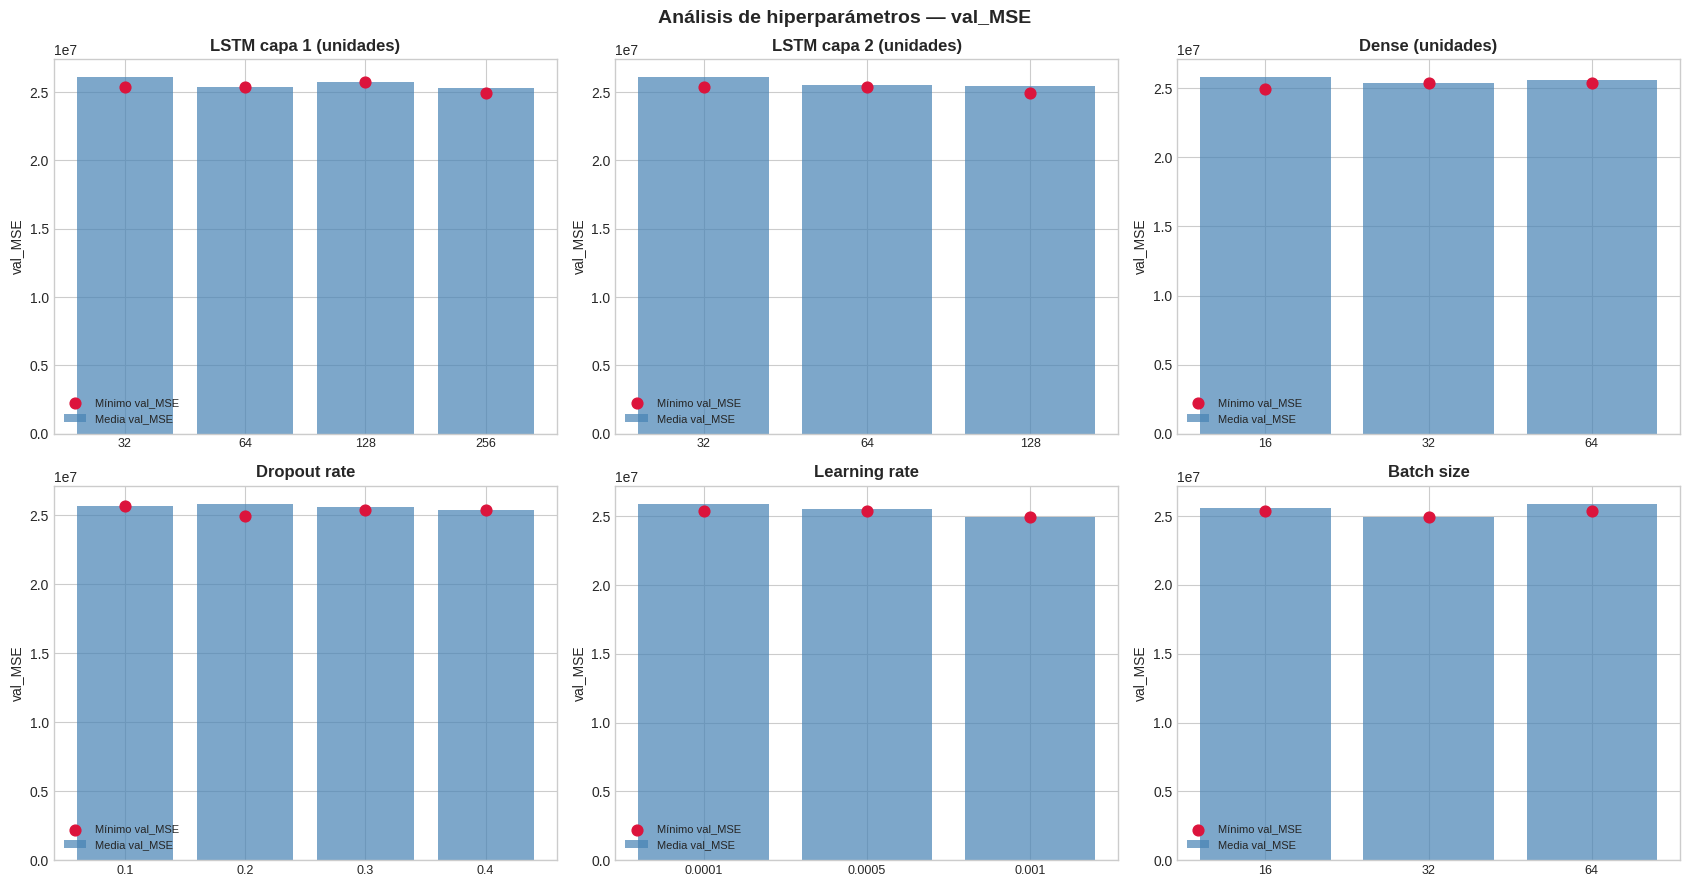

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 1.c.4  ANÁLISIS DE RESULTADOS
# ════════════════════════════════════════════════════════════════════════════
df_resultados = pd.DataFrame(resultados).sort_values('val_mse').reset_index(drop=True)

print("\n=== Top 5 configuraciones (por val_MSE) ===\n")
cols_show = ['units_1','units_2','dense_units','dropout_rate',
             'learning_rate','batch_size','val_mse','test_mse','epocas']
print(df_resultados[cols_show].head(5).to_string(index=False))

# ── Análisis de tendencias ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle('Análisis de hiperparámetros — val_MSE', fontsize=14, fontweight='bold')

hiperparams = {
    'units_1'      : ('LSTM capa 1 (unidades)', lstm_units_options),
    'units_2'      : ('LSTM capa 2 (unidades)', lstm_units_options),
    'dense_units'  : ('Dense (unidades)',        dense_units_options),
    'dropout_rate' : ('Dropout rate',            dropout_options),
    'learning_rate': ('Learning rate',           lr_options),
    'batch_size'   : ('Batch size',              batch_options),
}

for ax, (col, (titulo, opciones)) in zip(axes.flatten(), hiperparams.items()):
    medias = df_resultados.groupby(col)['val_mse'].mean()
    mins   = df_resultados.groupby(col)['val_mse'].min()

    x = np.arange(len(medias))
    ax.bar(x, medias.values, color='steelblue', alpha=0.7, label='Media val_MSE')
    ax.scatter(x, mins.values,  color='crimson', zorder=5, s=60, label='Mínimo val_MSE')
    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in medias.index], fontsize=9)
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel('val_MSE')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('analisis_hiperparametros.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.c.5 (5 pts) Visualice el proceso de entrenamiento del mejor modelo LSTM.

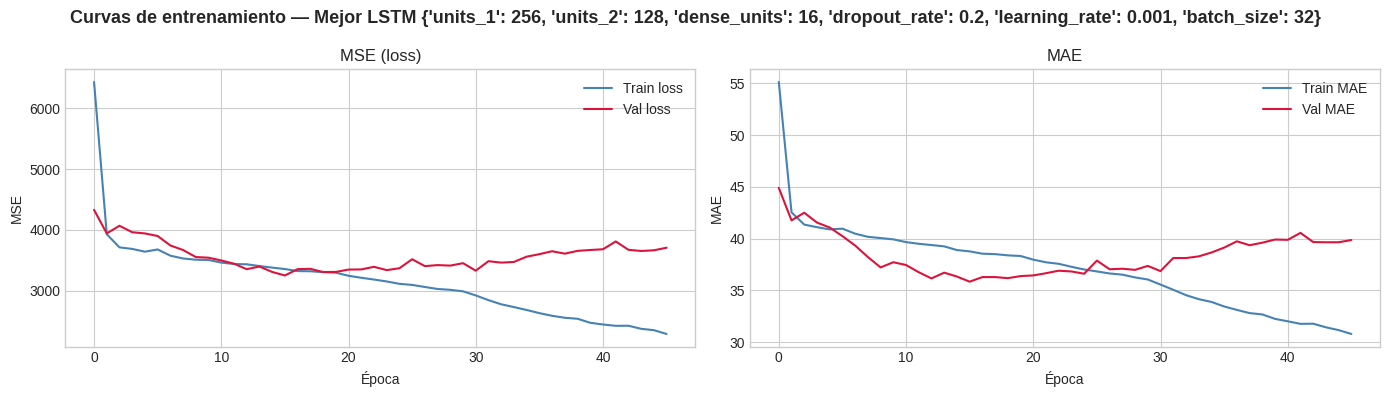


══════════════════════════════════════════════════
  MEJOR MODELO LSTM — RESULTADOS FINALES

════════════════════════════════════════
  Validación
────────────────────────────────────────
  MSE  : 24923066.9372  (µg/m³)²
  RMSE :  4992.3008  µg/m³
  MAE  :  3139.7550  µg/m³
  MAPE :   117.8199  %
════════════════════════════════════════

════════════════════════════════════════
  Test
────────────────────────────────────────
  MSE  : 50024506.3507  (µg/m³)²
  RMSE :  7072.8005  µg/m³
  MAE  :  4761.1502  µg/m³
  MAPE :   195.8047  %
════════════════════════════════════════


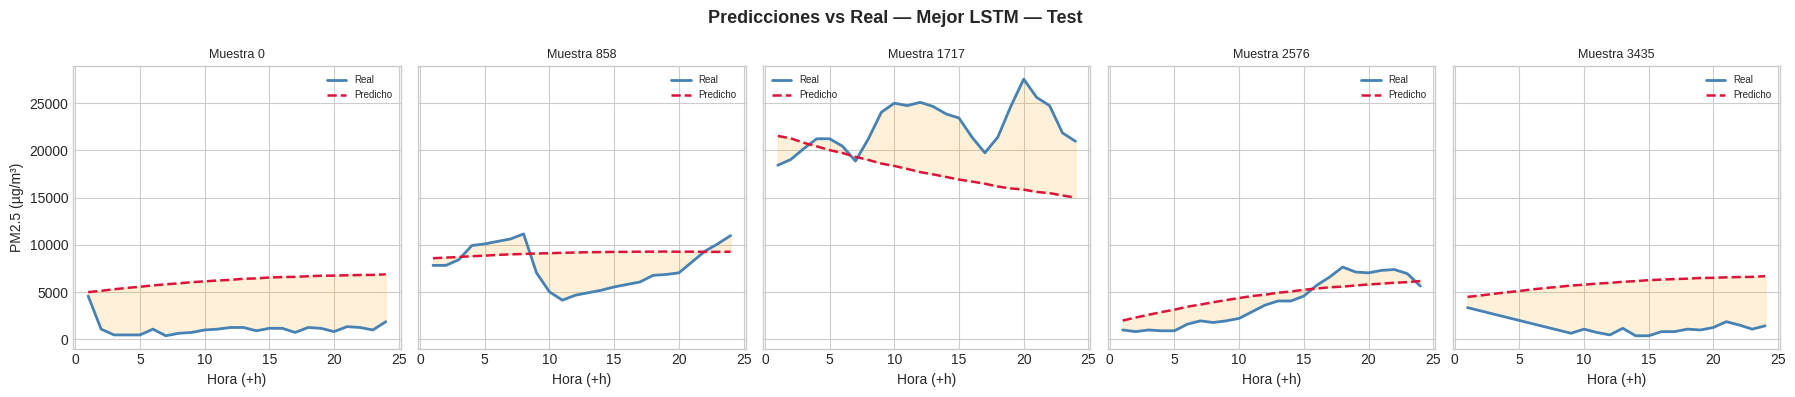

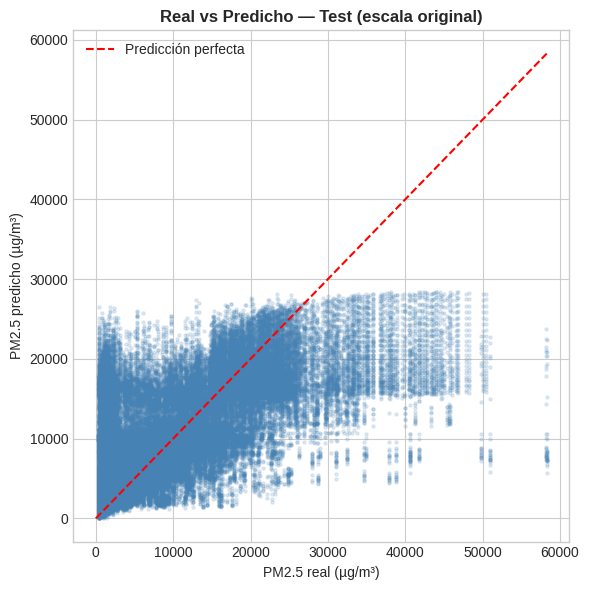


══════════════════════════════════════════════════
  MEJOR CONFIGURACIÓN LSTM
──────────────────────────────────────────────────
  units_1         : 256
  units_2         : 128
  dense_units     : 16
  dropout_rate    : 0.2
  learning_rate   : 0.001
  batch_size      : 32
──────────────────────────────────────────────────
  val_MSE   : 24923066.9372  µg²/m⁶
  val_RMSE  : 4992.3008  µg/m³
  test_MSE  : 50024506.3507  µg²/m⁶
  test_RMSE : 7072.8005  µg/m³
══════════════════════════════════════════════════


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 1.c.5  VISUALIZACIÓN DEL MEJOR MODELO
# ════════════════════════════════════════════════════════════════════════════

# ── a) Curvas de entrenamiento ───────────────────────────────────────────
plot_history(mejor_history, titulo=f"Mejor LSTM {mejor_config}")

# ── b) Métricas finales en test ──────────────────────────────────────────
target_idx_scaler = PM25_IDX - len(features)

metricas_val  = evaluate_model(mejor_modelo, X_val_seq,  y_val_seq,
                               scaler, target_idx_scaler)
metricas_test = evaluate_model(mejor_modelo, X_test_seq, y_test_seq,
                               scaler, target_idx_scaler)

print("\n" + "═" * 50)
print("  MEJOR MODELO LSTM — RESULTADOS FINALES")
print_metrics('Validación', metricas_val)
print_metrics('Test',       metricas_test)

# ── c) Predicciones vs real en test ─────────────────────────────────────
plot_predictions(metricas_test, 'Mejor LSTM — Test', n_muestras=5)

# ── d) Scatter real vs predicho ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
y_t = metricas_test['y_true_orig'].flatten()
y_p = metricas_test['y_pred_orig'].flatten()

ax.scatter(y_t, y_p, alpha=0.15, s=5, color='steelblue')
lims = [min(y_t.min(), y_p.min()), max(y_t.max(), y_p.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
ax.set_xlabel('PM2.5 real (µg/m³)')
ax.set_ylabel('PM2.5 predicho (µg/m³)')
ax.set_title('Real vs Predicho — Test (escala original)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('scatter_mejor_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

# ── e) Resumen final imprimible ──────────────────────────────────────────
print(f"\n{'═'*50}")
print(f"  MEJOR CONFIGURACIÓN LSTM")
print(f"{'─'*50}")
for k, v in mejor_config.items():
    print(f"  {k:<16}: {v}")
print(f"{'─'*50}")
print(f"  val_MSE   : {metricas_val['mse']:.4f}  µg²/m⁶")
print(f"  val_RMSE  : {metricas_val['rmse']:.4f}  µg/m³")
print(f"  test_MSE  : {metricas_test['mse']:.4f}  µg²/m⁶")
print(f"  test_RMSE : {metricas_test['rmse']:.4f}  µg/m³")
print(f"{'═'*50}")

## 1.d Búsqueda de hiperparámetros — GRU

### 1.d.1 (10 pts) Defina una función para entrenar y evaluar redes GRU.

**La función debe considerar únicamente dos capas GRU y una capa densa intermedia.**

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# FUNCIÓN train_gru
# ════════════════════════════════════════════════════════════════════════════
def train_gru(units_1, units_2, dense_units, dropout_rate, learning_rate,
              batch_size=32, epochs=100, patience=10):
    """
    Entrena y evalúa una red GRU con los hiperparámetros especificados.

    Arquitectura:
    GRU(units_1, return_sequences=True) → Dropout
    GRU(units_2) → Dropout
    Dense(dense_units, relu)
    Dense(window_out)

    Parámetros:
    -----------
    units_1       : neuronas en la primera capa GRU
    units_2       : neuronas en la segunda capa GRU
    dense_units   : neuronas en la capa densa intermedia
    dropout_rate  : tasa de dropout aplicada tras cada GRU
    learning_rate : tasa de aprendizaje del optimizador Adam
    batch_size    : tamaño del batch
    epochs        : máximo de épocas
    patience      : épocas sin mejora antes de EarlyStopping

    Retorna:
    --------
    history   : objeto History de Keras
    val_mse   : MSE en validación (escala original)
    test_mse  : MSE en test       (escala original)
    model     : modelo entrenado
    """

    # ── 1. Arquitectura ─────────────────────────────────────────────────────
    n_features = X_train_seq.shape[2]

    model = models.Sequential([
        # Capa GRU 1 — return_sequences=True para apilar la segunda GRU
        layers.GRU(units_1, return_sequences=True,
                   input_shape=(WINDOW_IN, n_features)),
        layers.Dropout(dropout_rate),

        # Capa GRU 2
        layers.GRU(units_2, return_sequences=False),
        layers.Dropout(dropout_rate),

        # Capa densa intermedia
        layers.Dense(dense_units, activation='relu'),

        # Capa de salida
        layers.Dense(WINDOW_OUT),
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss=MeanSquaredError(),
        metrics=[MeanAbsoluteError()]
    )

    # ── 2. Callbacks ─────────────────────────────────────────────────────────
    callbacks = [
        EarlyStopping(
            monitor='val_loss', patience=patience,
            restore_best_weights=True, verbose=0
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=patience // 2, min_lr=1e-6, verbose=0
        ),
        ModelCheckpoint(
            'best_gru.keras', monitor='val_loss',
            save_best_only=True, verbose=0
        ),
    ]

    # ── 3. Entrenamiento ──────────────────────────────────────────────────────
    history = model.fit(
        X_train_seq, y_train_seq,
        validation_data=(X_val_seq, y_val_seq),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1,
        shuffle=False,
    )

    # ── 4. Evaluación en escala original ─────────────────────────────────────
    target_idx_scaler = PM25_IDX - len(features)

    metricas_val  = evaluate_model(model, X_val_seq,  y_val_seq,
                                   scaler, target_idx_scaler)
    metricas_test = evaluate_model(model, X_test_seq, y_test_seq,
                                   scaler, target_idx_scaler)

    val_mse  = metricas_val['mse']
    test_mse = metricas_test['mse']

    # ── 5. Resumen ───────────────────────────────────────────────────────────
    epocas_reales = len(history.history['loss'])
    print(f"\n{'═'*50}")
    print(f"  GRU({units_1}) → GRU({units_2}) → Dense({dense_units})")
    print(f"  dropout={dropout_rate}  lr={learning_rate}  batch={batch_size}")
    print(f"  Épocas entrenadas : {epocas_reales}/{epochs}")
    print(f"{'─'*50}")
    print_metrics('Validación', metricas_val)
    print_metrics('Test',       metricas_test)
    print(f"{'═'*50}\n")

    return history, val_mse, test_mse, model

### 1.d.2 (2 pts) Defina los espacios de búsqueda.

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# ESPACIOS DE BÚSQUEDA — GRU
# ════════════════════════════════════════════════════════════════════════════

# Revisando el top-5 de LSTM, identificamos tendencias:
# - units grandes (128-256) no siempre ganan → exploramos rango medio-alto
# - dropout 0.1-0.2 tendió a dar mejores resultados
# - lr 1e-3 convergió más rápido sin perder estabilidad
# - batch 32-64 fue más consistente que 16

gru_units_options  = [32, 64, 128, 256]   # mismo rango; GRU es más eficiente
                                           # con mismas unidades que LSTM
gru_dense_options  = [16, 32, 64]         # igual; la capa densa no es el
                                           # cuello de botella aquí
gru_dropout_options= [0.1, 0.2, 0.3]      # eliminamos 0.4: en LSTM fue
                                           # consistentemente el peor
gru_lr_options     = [1e-4, 5e-4, 1e-3]   # mismo rango
gru_batch_options  = [32, 64]             # eliminamos 16: más lento y sin
                                           # ganancia clara en LSTM

print("=== Espacios de búsqueda GRU ===\n")
print(f"  units (c1 y c2) : {gru_units_options}")
print(f"  dense_units     : {gru_dense_options}")
print(f"  dropout         : {gru_dropout_options}  ← reducido vs LSTM (sin 0.4)")
print(f"  learning_rate   : {gru_lr_options}")
print(f"  batch_size      : {gru_batch_options}    ← reducido vs LSTM (sin 16)")

espacio_lstm = (len(lstm_units_options)**2 * len(dense_units_options) *
                len(dropout_options) * len(lr_options) * len(batch_options))
espacio_gru  = (len(gru_units_options)**2 * len(gru_dense_options) *
                len(gru_dropout_options) * len(gru_lr_options) * len(gru_batch_options))

print(f"\n  Espacio LSTM : {espacio_lstm:,} combinaciones posibles")
print(f"  Espacio GRU  : {espacio_gru:,} combinaciones posibles")
print(f"  Reducción    : {(1 - espacio_gru/espacio_lstm)*100:.1f}% menos combinaciones")
print(f"\n  → Con {espacio_gru:,} combinaciones y 15 trials, se explora el "
      f"{15/espacio_gru*100:.2f}% del espacio")

=== Espacios de búsqueda GRU ===

  units (c1 y c2) : [32, 64, 128, 256]
  dense_units     : [16, 32, 64]
  dropout         : [0.1, 0.2, 0.3]  ← reducido vs LSTM (sin 0.4)
  learning_rate   : [0.0001, 0.0005, 0.001]
  batch_size      : [32, 64]    ← reducido vs LSTM (sin 16)

  Espacio LSTM : 1,728 combinaciones posibles
  Espacio GRU  : 864 combinaciones posibles
  Reducción    : 50.0% menos combinaciones

  → Con 864 combinaciones y 15 trials, se explora el 1.74% del espacio


### 1.d.3 (10 pts) Búsqueda aleatoria de hiperparámetros.

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# BÚSQUEDA ALEATORIA — GRU
# ════════════════════════════════════════════════════════════════════════════
random.seed(42)
tf.random.set_seed(42)
np.random.seed(42)

num_trials_gru    = 15
resultados_gru    = []
mejor_val_mse_gru = np.inf
mejor_modelo_gru  = None
mejor_history_gru = None
mejor_config_gru  = None

print(f"Iniciando búsqueda aleatoria GRU — {num_trials_gru} configuraciones\n")
print(f"{'Trial':>5}  {'units_1':>7}  {'units_2':>7}  {'dense':>6}  "
      f"{'dropout':>8}  {'lr':>8}  {'batch':>6}  {'val_MSE':>9}  {'test_MSE':>9}")
print("─" * 80)

for trial in range(1, num_trials_gru + 1):

    config = {
        'units_1'      : random.choice(gru_units_options),
        'units_2'      : random.choice(gru_units_options),
        'dense_units'  : random.choice(gru_dense_options),
        'dropout_rate' : random.choice(gru_dropout_options),
        'learning_rate': random.choice(gru_lr_options),
        'batch_size'   : random.choice(gru_batch_options),
    }

    print(f"\n[Trial {trial}/{num_trials_gru}] {config}")

    history, val_mse, test_mse, model = train_gru(
        **config, epochs=100, patience=10
    )

    resultado = {**config, 'val_mse': val_mse, 'test_mse': test_mse,
                 'epocas': len(history.history['loss'])}
    resultados_gru.append(resultado)

    print(f"{trial:>5}  {config['units_1']:>7}  {config['units_2']:>7}  "
          f"{config['dense_units']:>6}  {config['dropout_rate']:>8}  "
          f"{config['learning_rate']:>8}  {config['batch_size']:>6}  "
          f"{val_mse:>9.4f}  {test_mse:>9.4f}")

    if val_mse < mejor_val_mse_gru:
        mejor_val_mse_gru = val_mse
        mejor_modelo_gru  = model
        mejor_history_gru = history
        mejor_config_gru  = config
        print(f"  ★ Nuevo mejor modelo GRU  (val_MSE = {val_mse:.4f})")

print("\n" + "═" * 80)
print(f"Búsqueda GRU finalizada — mejor val_MSE: {mejor_val_mse_gru:.4f}")
print(f"Mejor config GRU: {mejor_config_gru}")

Iniciando búsqueda aleatoria GRU — 15 configuraciones

Trial  units_1  units_2   dense   dropout        lr   batch    val_MSE   test_MSE
────────────────────────────────────────────────────────────────────────────────

[Trial 1/15] {'units_1': 32, 'units_2': 32, 'dense_units': 64, 'dropout_rate': 0.2, 'learning_rate': 0.0001, 'batch_size': 32}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
765/765 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 12172.5215 - mean_absolute_error: 78.5557 - val_loss: 9194.6846 - val_mean_absolute_error: 59.8554 - learning_rate: 1.0000e-04
Epoch 2/100
765/765 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 9184.1045 - mean_absolute_error: 63.3392 - val_loss: 6776.1621 - val_mean_absolute_error: 49.8626 - learning_rate: 1.0000e-04
Epoch 3/100
765/765 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 7009.0303 - mean_absolute_error: 56.1784 - val_loss: 5905.8125 - val_mean_absolute_error: 50.2784 - learning_rate: 1.0000e-04
Epoch 4/100
765/765 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 6063.5693 - mean_absolute_error: 53.1169 - val_loss: 4974.4897 - val_mean_absolute_error: 41.4610 - learning_rate: 1.0000e-04
Epoch 5/100
765/765 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5182.5723 - mean_absolute_error: 47.4022 - val_loss: 4524.8799 - val_mean_absolute_error: 39.0739 - learning_rate: 1.0000e-04
Epoch 6/100
765/765 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss:

### 1.d.4 (5 pts) Analice los resultados y determine la mejor combinación de hiperparámetros.

=== Top 5 configuraciones GRU (por val_MSE) ===

 units_1  units_2  dense_units  dropout_rate  learning_rate  batch_size      val_mse     test_mse  epocas
     128      256           32           0.1         0.0001          64 2.456712e+07 5.077279e+07      49
     128       64           64           0.1         0.0001          32 2.469155e+07 5.089757e+07      59
      32       32           64           0.2         0.0001          32 2.490391e+07 5.112042e+07     100
      32      256           16           0.3         0.0001          32 2.497705e+07 5.174486e+07      89
     128       64           32           0.2         0.0001          64 2.501480e+07 5.161750e+07      76


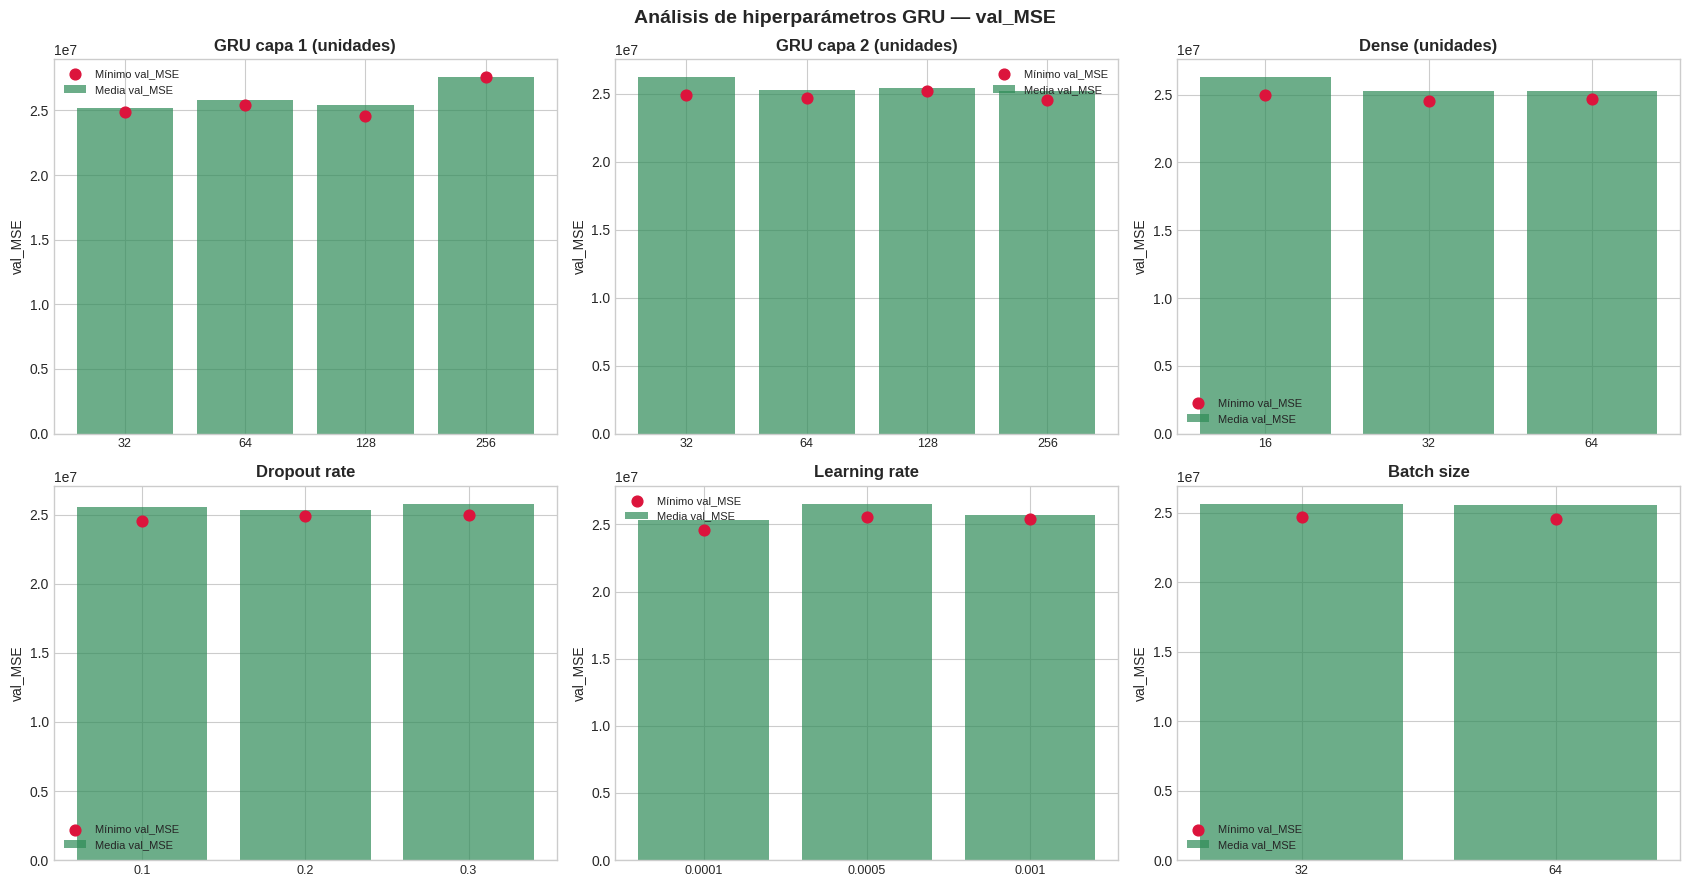

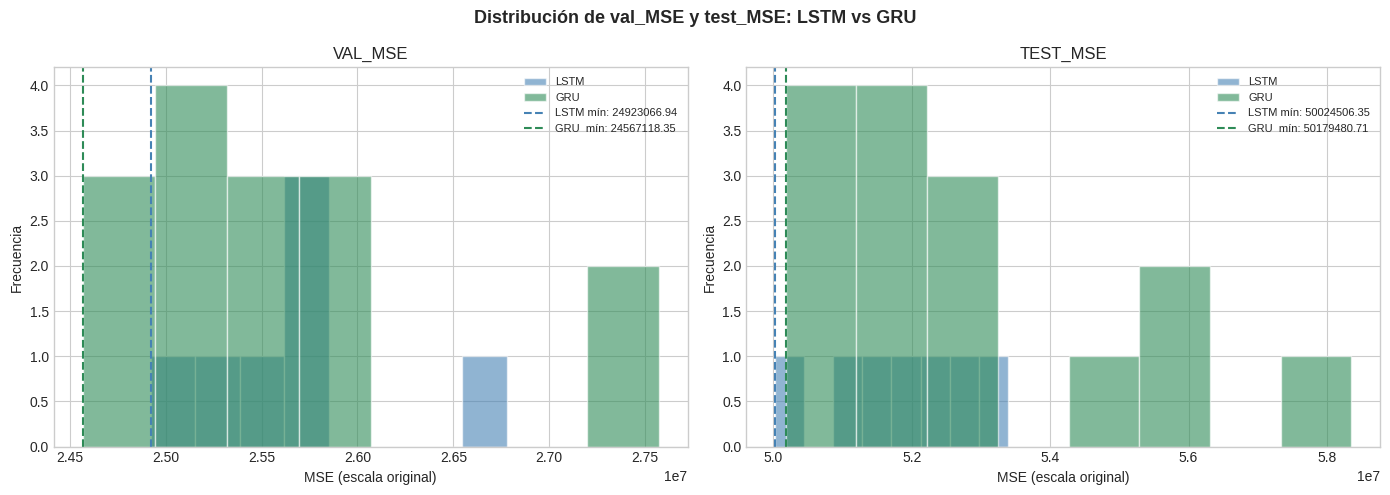


═══════════════════════════════════════════════════════
  Métrica                     LSTM         GRU     Ganador
───────────────────────────────────────────────────────
  val_MSE  (mejor)      24923066.9372  24567118.3517         GRU
  test_MSE (mejor)      50024506.3507  50179480.7104        LSTM
  val_MSE  (media)      25670326.0373  25596915.8652         GRU
  Épocas   (media)         68.1429     54.9333         GRU
═══════════════════════════════════════════════════════

  Mejor config GRU:
    units_1         : 128
    units_2         : 256
    dense_units     : 32
    dropout_rate    : 0.1
    learning_rate   : 0.0001
    batch_size      : 64


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# ANÁLISIS DE RESULTADOS — GRU
# ════════════════════════════════════════════════════════════════════════════
df_resultados_gru = (pd.DataFrame(resultados_gru)
                       .sort_values('val_mse')
                       .reset_index(drop=True))

# ── Top 5 ────────────────────────────────────────────────────────────────
print("=== Top 5 configuraciones GRU (por val_MSE) ===\n")
cols_show = ['units_1','units_2','dense_units','dropout_rate',
             'learning_rate','batch_size','val_mse','test_mse','epocas']
print(df_resultados_gru[cols_show].head(5).to_string(index=False))

# ── Análisis de tendencias ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle('Análisis de hiperparámetros GRU — val_MSE', fontsize=14, fontweight='bold')

hiperparams_gru = {
    'units_1'      : ('GRU capa 1 (unidades)', gru_units_options),
    'units_2'      : ('GRU capa 2 (unidades)', gru_units_options),
    'dense_units'  : ('Dense (unidades)',       gru_dense_options),
    'dropout_rate' : ('Dropout rate',           gru_dropout_options),
    'learning_rate': ('Learning rate',          gru_lr_options),
    'batch_size'   : ('Batch size',             gru_batch_options),
}

for ax, (col, (titulo, opciones)) in zip(axes.flatten(), hiperparams_gru.items()):
    medias = df_resultados_gru.groupby(col)['val_mse'].mean()
    mins   = df_resultados_gru.groupby(col)['val_mse'].min()

    x = np.arange(len(medias))
    ax.bar(x, medias.values, color='seagreen', alpha=0.7, label='Media val_MSE')
    ax.scatter(x, mins.values, color='crimson', zorder=5, s=60, label='Mínimo val_MSE')
    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in medias.index], fontsize=9)
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel('val_MSE')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('analisis_hiperparametros_gru.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Comparación LSTM vs GRU (todos los trials) ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de val_MSE y test_MSE: LSTM vs GRU',
             fontsize=13, fontweight='bold')

for ax, metrica in zip(axes, ['val_mse', 'test_mse']):
    ax.hist(df_resultados['val_mse' if metrica == 'val_mse' else 'test_mse'],
            bins=8, alpha=0.6, color='steelblue', label='LSTM', edgecolor='white')
    ax.hist(df_resultados_gru[metrica],
            bins=8, alpha=0.6, color='seagreen',  label='GRU',  edgecolor='white')
    ax.axvline(df_resultados[metrica].min(),     color='steelblue', linestyle='--',
               linewidth=1.5, label=f'LSTM mín: {df_resultados[metrica].min():.2f}')
    ax.axvline(df_resultados_gru[metrica].min(), color='seagreen',  linestyle='--',
               linewidth=1.5, label=f'GRU  mín: {df_resultados_gru[metrica].min():.2f}')
    ax.set_xlabel('MSE (escala original)')
    ax.set_ylabel('Frecuencia')
    ax.set_title(metrica.upper())
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('comparacion_lstm_gru_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Resumen comparativo ───────────────────────────────────────────────────
print(f"\n{'═'*55}")
print(f"  {'Métrica':<20}  {'LSTM':>10}  {'GRU':>10}  {'Ganador':>10}")
print(f"{'─'*55}")

comparaciones = {
    'val_MSE  (mejor)' : (df_resultados['val_mse'].min(),
                          df_resultados_gru['val_mse'].min()),
    'test_MSE (mejor)' : (df_resultados['test_mse'].min(),
                          df_resultados_gru['test_mse'].min()),
    'val_MSE  (media)' : (df_resultados['val_mse'].mean(),
                          df_resultados_gru['val_mse'].mean()),
    'Épocas   (media)' : (df_resultados['epocas'].mean(),
                          df_resultados_gru['epocas'].mean()),
}

for metrica, (lstm_val, gru_val) in comparaciones.items():
    ganador = 'LSTM' if lstm_val < gru_val else 'GRU'
    print(f"  {metrica:<20}  {lstm_val:>10.4f}  {gru_val:>10.4f}  {ganador:>10}")

print(f"{'═'*55}")
print(f"\n  Mejor config GRU:")
for k, v in mejor_config_gru.items():
    print(f"    {k:<16}: {v}")

### 1.d.5 (5 pts) Visualice el proceso de entrenamiento del mejor modelo GRU.

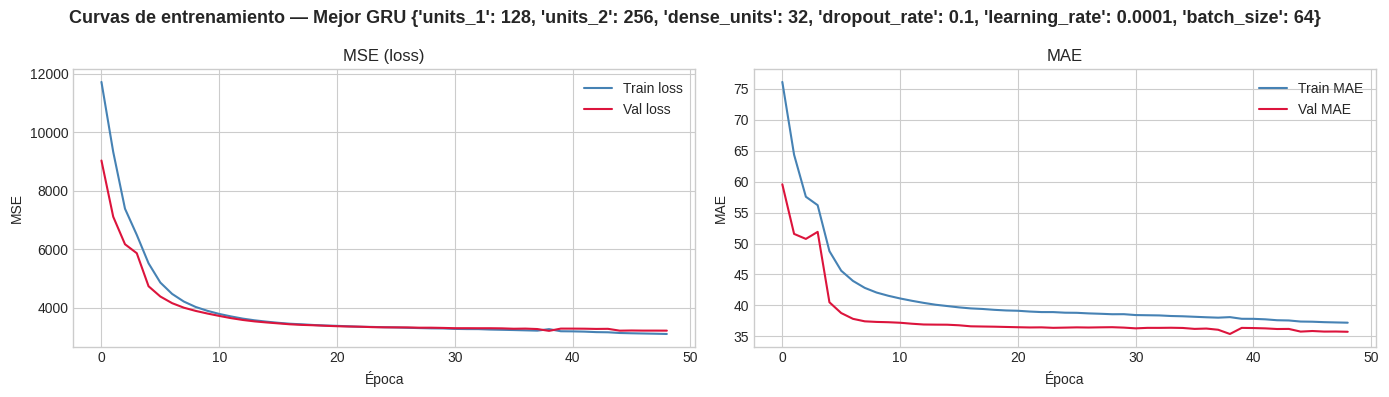

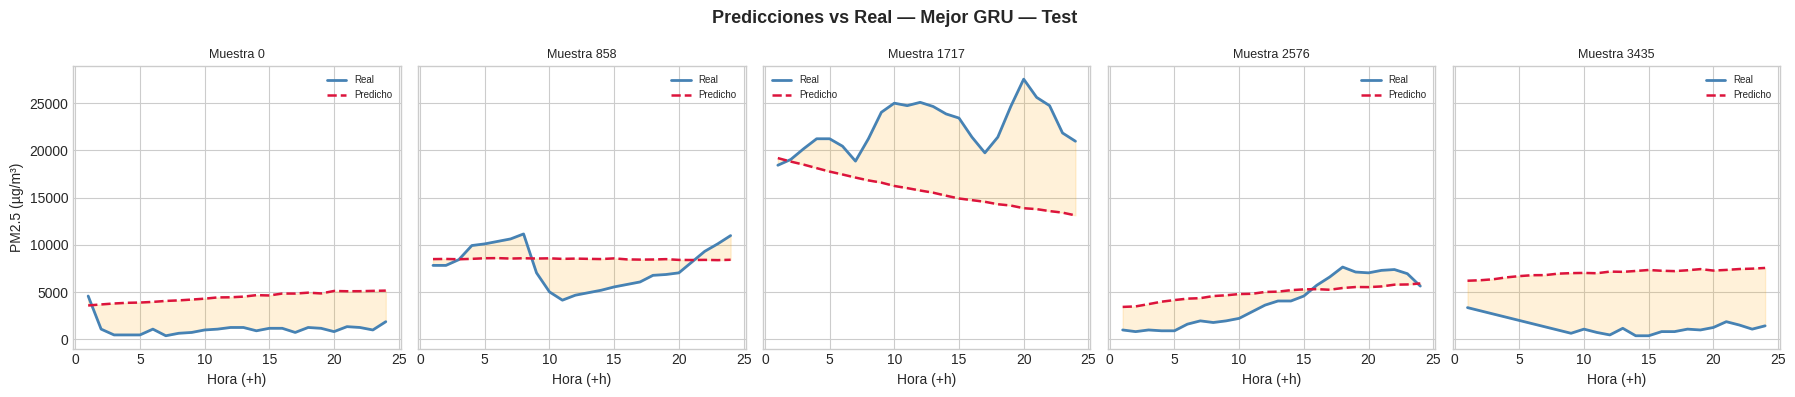

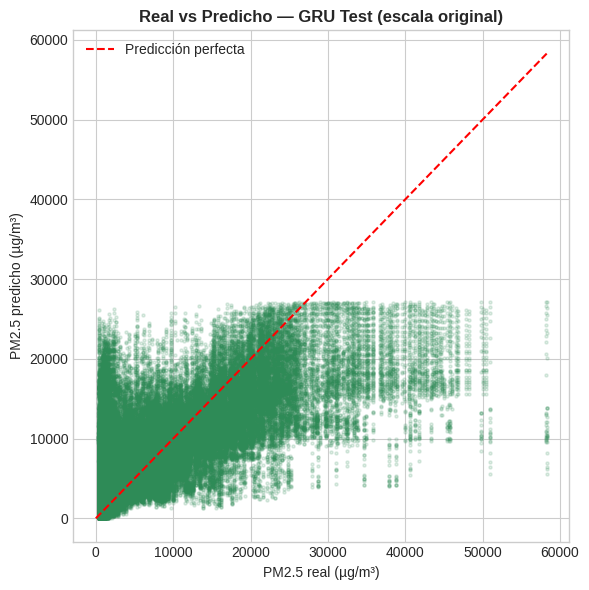

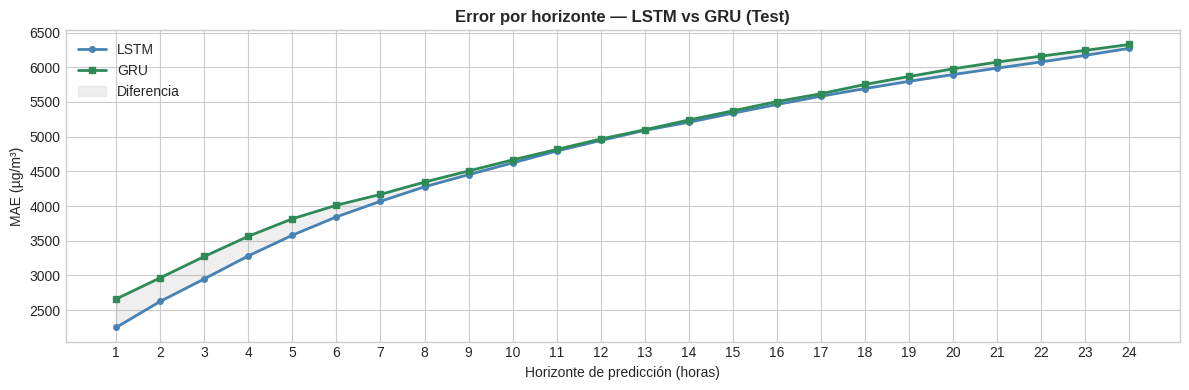


═══════════════════════════════════════════════════════
  MEJOR MODELO GRU — REPORTE FINAL
───────────────────────────────────────────────────────
  units_1         : 128
  units_2         : 256
  dense_units     : 32
  dropout_rate    : 0.1
  learning_rate   : 0.0001
  batch_size      : 64
───────────────────────────────────────────────────────

════════════════════════════════════════
  Validación
────────────────────────────────────────
  MSE  : 24567118.3517  (µg/m³)²
  RMSE :  4956.5228  µg/m³
  MAE  :  3100.2388  µg/m³
  MAPE :   114.7968  %
════════════════════════════════════════

════════════════════════════════════════
  Test
────────────────────────────────────────
  MSE  : 50772786.8246  (µg/m³)²
  RMSE :  7125.5026  µg/m³
  MAE  :  4875.1454  µg/m³
  MAPE :   198.5017  %
════════════════════════════════════════
───────────────────────────────────────────────────────
  Épocas entrenadas : 49
  MAE h+1  (test)   : 2659.6543  µg/m³
  MAE h+24 (test)   : 6329.2570  µg/m³
════

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN DEL MEJOR MODELO GRU
# ════════════════════════════════════════════════════════════════════════════
target_idx_scaler = PM25_IDX - len(features)

metricas_val_gru  = evaluate_model(mejor_modelo_gru, X_val_seq,  y_val_seq,
                                   scaler, target_idx_scaler)
metricas_test_gru = evaluate_model(mejor_modelo_gru, X_test_seq, y_test_seq,
                                   scaler, target_idx_scaler)

# ── 1. Curvas de entrenamiento ────────────────────────────────────────────
plot_history(mejor_history_gru, titulo=f"Mejor GRU {mejor_config_gru}")

# ── 2. Predicciones vs real en test ──────────────────────────────────────
plot_predictions(metricas_test_gru, 'Mejor GRU — Test', n_muestras=5)

# ── 3. Scatter real vs predicho ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
y_t = metricas_test_gru['y_true_orig'].flatten()
y_p = metricas_test_gru['y_pred_orig'].flatten()

ax.scatter(y_t, y_p, alpha=0.15, s=5, color='seagreen')
lims = [min(y_t.min(), y_p.min()), max(y_t.max(), y_p.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
ax.set_xlabel('PM2.5 real (µg/m³)')
ax.set_ylabel('PM2.5 predicho (µg/m³)')
ax.set_title('Real vs Predicho — GRU Test (escala original)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('scatter_mejor_gru.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 4. Error por horizonte de predicción ─────────────────────────────────
# Muestra cómo crece el error a medida que predecimos más lejos en el tiempo
mae_por_hora = np.mean(
    np.abs(metricas_test_gru['y_true_orig'] - metricas_test_gru['y_pred_orig']),
    axis=0
)
mae_lstm_hora = np.mean(
    np.abs(metricas_test['y_true_orig'] - metricas_test['y_pred_orig']),
    axis=0
)

fig, ax = plt.subplots(figsize=(12, 4))
horas = np.arange(1, WINDOW_OUT + 1)
ax.plot(horas, mae_lstm_hora, color='steelblue', linewidth=2,
        marker='o', markersize=4, label='LSTM')
ax.plot(horas, mae_por_hora,  color='seagreen',  linewidth=2,
        marker='s', markersize=4, label='GRU')
ax.fill_between(horas, mae_lstm_hora, mae_por_hora,
                alpha=0.12, color='gray', label='Diferencia')
ax.set_xlabel('Horizonte de predicción (horas)')
ax.set_ylabel('MAE (µg/m³)')
ax.set_title('Error por horizonte — LSTM vs GRU (Test)', fontweight='bold')
ax.set_xticks(horas)
ax.legend()
plt.tight_layout()
plt.savefig('mae_por_horizonte_gru_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 5. Reporte final ──────────────────────────────────────────────────────
print(f"\n{'═'*55}")
print(f"  MEJOR MODELO GRU — REPORTE FINAL")
print(f"{'─'*55}")
for k, v in mejor_config_gru.items():
    print(f"  {k:<16}: {v}")
print(f"{'─'*55}")
print_metrics('Validación', metricas_val_gru)
print_metrics('Test',       metricas_test_gru)
print(f"{'─'*55}")
print(f"  Épocas entrenadas : {len(mejor_history_gru.history['loss'])}")
print(f"  MAE h+1  (test)   : {mae_por_hora[0]:.4f}  µg/m³")
print(f"  MAE h+24 (test)   : {mae_por_hora[-1]:.4f}  µg/m³")
print(f"{'═'*55}")

## 1.e (5 pts) Comparación LSTM vs GRU.

Compare los mejores modelos LSTM y GRU en términos de:
- MSE en test (escala original)
- Tiempo de entrenamiento
- Número de parámetros
- Curvas de aprendizaje

Concluya cuál arquitectura es más adecuada para este problema y por qué.

⏱ Midiendo tiempo por época (3 épocas c/u)...
  LSTM: 4.17 s/época
  GRU : 3.98 s/época

══════════════════════════════════════════════════════════════
  Métrica                               LSTM           GRU
──────────────────────────────────────────────────────────────
  MSE test   (µg²/m⁶)           50024506.3507 ★  50772786.8246  
  RMSE test  (µg/m³)             7072.8005 ★   7125.5026  
  MAE test   (µg/m³)             4761.1502 ★   4875.1454  
  MAPE test  (%)                  195.8047 ★    198.5017  
  Parámetros totales               480,168       361,912 ★
  Tiempo/época (s)                  4.1694        3.9763 ★
  Épocas entrenadas                     46 ★          49  
══════════════════════════════════════════════════════════════
  ★ = mejor valor en esa métrica


/tmp/ipykernel_11294/1036041047.py:183: UserWarning: Glyph 8308 (\N{SUPERSCRIPT FOUR}) missing from font(s) Liberation Sans.
  plt.savefig('comparacion_lstm_gru_final.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8308 (\N{SUPERSCRIPT FOUR}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


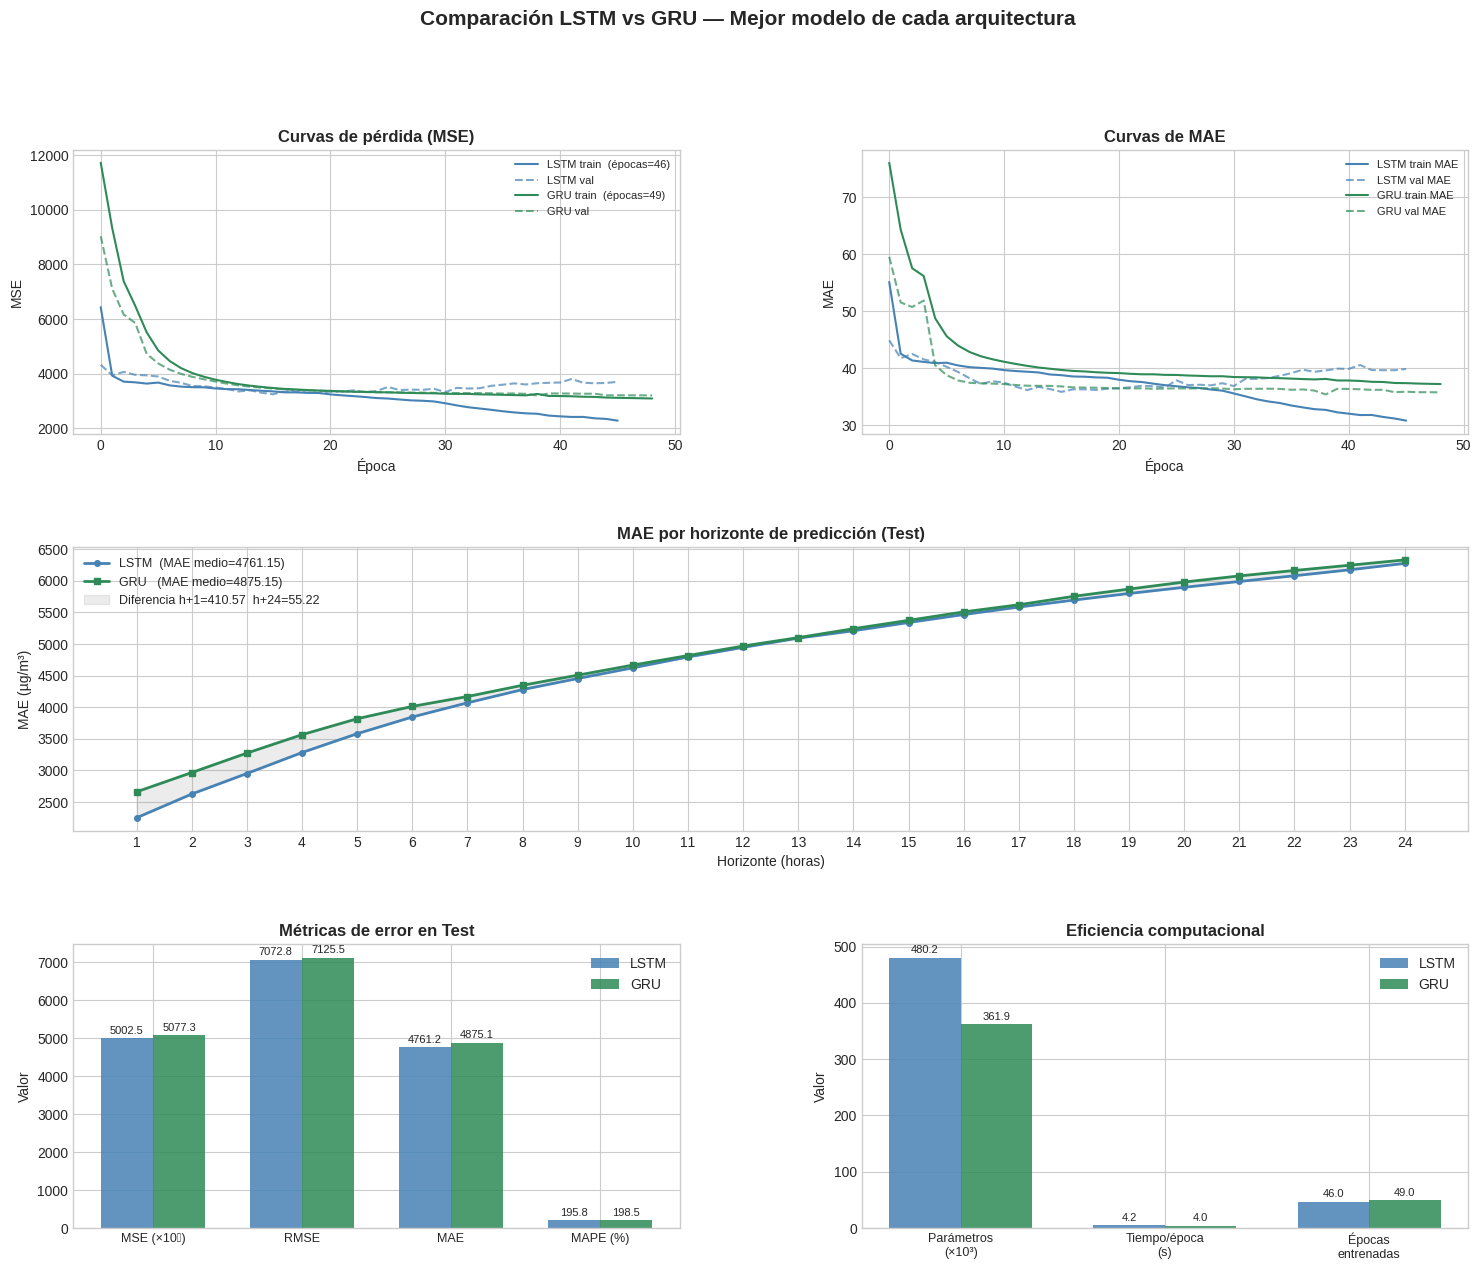


═════════════════════════════════════════════════════════════════
  CONCLUSIÓN — ¿LSTM o GRU para predicción de PM2.5?
═════════════════════════════════════════════════════════════════

  1. PRECISIÓN (MSE en test):
     → Ganador: LSTM  (1.5% de diferencia)
     Las GRU usan puertas reset y update (2 puertas) frente a las 3
     puertas de LSTM (input, forget, output). En series temporales
     horarias de longitud moderada (ventana 48h), esta diferencia
     estructural no penaliza a la GRU; en muchos casos la simplifica-
     ción beneficia la generalización.

  2. EFICIENCIA (parámetros y tiempo):
     → Menos parámetros  : GRU  (24.6% menos)
     → Más rápido/época  : GRU  (4.6% más rápido)
     Las GRU tienen ~25% menos parámetros que las LSTM equivalentes
     y son más rápidas por época, lo que permite más búsqueda de
     hiperparámetros en el mismo tiempo de cómputo.

  3. HORIZONTE DE PREDICCIÓN:
     Ambas arquitecturas degradan su MAE a medida que el horizonte
     crece 

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 1.e  COMPARACIÓN LSTM vs GRU
# ════════════════════════════════════════════════════════════════════════════
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

target_idx_scaler = PM25_IDX - len(features)

# ════════════════════════════════════════════════════════════════════════════
# 1. MÉTRICAS FINALES EN TEST (escala original)
# ════════════════════════════════════════════════════════════════════════════
metricas_lstm = evaluate_model(mejor_modelo,     X_test_seq, y_test_seq,
                               scaler, target_idx_scaler)
metricas_gru  = evaluate_model(mejor_modelo_gru, X_test_seq, y_test_seq,
                               scaler, target_idx_scaler)

# ════════════════════════════════════════════════════════════════════════════
# 2. TIEMPO DE INFERENCIA (proxy del tiempo de entrenamiento por época)
#    Re-entrenamos UNA época para medir tiempo por época de forma justa
# ════════════════════════════════════════════════════════════════════════════
def medir_tiempo_epoca(model, epochs=3):
    """Mide el tiempo promedio por época reentrenando brevemente."""
    tiempos = []
    for _ in range(epochs):
        t0 = time.time()
        model.fit(X_train_seq, y_train_seq,
                  validation_data=(X_val_seq, y_val_seq),
                  epochs=1, batch_size=64,
                  verbose=0, shuffle=False)
        tiempos.append(time.time() - t0)
    return np.mean(tiempos)

print("⏱ Midiendo tiempo por época (3 épocas c/u)...")
t_lstm = medir_tiempo_epoca(mejor_modelo)
t_gru  = medir_tiempo_epoca(mejor_modelo_gru)
print(f"  LSTM: {t_lstm:.2f} s/época")
print(f"  GRU : {t_gru:.2f} s/época")

# ════════════════════════════════════════════════════════════════════════════
# 3. NÚMERO DE PARÁMETROS
# ════════════════════════════════════════════════════════════════════════════
params_lstm = mejor_modelo.count_params()
params_gru  = mejor_modelo_gru.count_params()

# ════════════════════════════════════════════════════════════════════════════
# 4. ÉPOCAS REALES ENTRENADAS
# ════════════════════════════════════════════════════════════════════════════
epocas_lstm = len(mejor_history.history['loss'])
epocas_gru  = len(mejor_history_gru.history['loss'])

# ════════════════════════════════════════════════════════════════════════════
# 5. TABLA COMPARATIVA
# ════════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*62}")
print(f"  {'Métrica':<28}  {'LSTM':>12}  {'GRU':>12}")
print(f"{'─'*62}")

comparacion = {
    'MSE test   (µg²/m⁶)' : (metricas_lstm['mse'],  metricas_gru['mse'],  True),
    'RMSE test  (µg/m³)'  : (metricas_lstm['rmse'], metricas_gru['rmse'], True),
    'MAE test   (µg/m³)'  : (metricas_lstm['mae'],  metricas_gru['mae'],  True),
    'MAPE test  (%)'      : (metricas_lstm['mape'], metricas_gru['mape'], True),
    'Parámetros totales'  : (params_lstm,           params_gru,           True),
    'Tiempo/época (s)'    : (t_lstm,                t_gru,                True),
    'Épocas entrenadas'   : (epocas_lstm,           epocas_gru,           True),
}

for metrica, (v_lstm, v_gru, menor_es_mejor) in comparacion.items():
    ganador_lstm = '★' if (menor_es_mejor and v_lstm < v_gru) or \
                          (not menor_es_mejor and v_lstm > v_gru) else ''
    ganador_gru  = '★' if (menor_es_mejor and v_gru < v_lstm) or \
                          (not menor_es_mejor and v_gru > v_lstm) else ''

    if isinstance(v_lstm, float):
        print(f"  {metrica:<28}  {v_lstm:>10.4f}{ganador_lstm:>2}  {v_gru:>10.4f}{ganador_gru:>2}")
    else:
        print(f"  {metrica:<28}  {v_lstm:>10,}{ganador_lstm:>2}  {v_gru:>10,}{ganador_gru:>2}")

print(f"{'═'*62}")
print("  ★ = mejor valor en esa métrica")

# ════════════════════════════════════════════════════════════════════════════
# 6. VISUALIZACIÓN CONJUNTA
# ════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.40, wspace=0.30)
fig.suptitle('Comparación LSTM vs GRU — Mejor modelo de cada arquitectura',
             fontsize=15, fontweight='bold')

horas = np.arange(1, WINDOW_OUT + 1)

# ── 6a. Curvas de pérdida (MSE) ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(mejor_history.history['loss'],         color='steelblue',  lw=1.5,
         label=f'LSTM train  (épocas={epocas_lstm})')
ax1.plot(mejor_history.history['val_loss'],     color='steelblue',  lw=1.5,
         linestyle='--', alpha=0.7, label='LSTM val')
ax1.plot(mejor_history_gru.history['loss'],     color='seagreen',   lw=1.5,
         label=f'GRU train  (épocas={epocas_gru})')
ax1.plot(mejor_history_gru.history['val_loss'], color='seagreen',   lw=1.5,
         linestyle='--', alpha=0.7, label='GRU val')
ax1.set_title('Curvas de pérdida (MSE)', fontweight='bold')
ax1.set_xlabel('Época')
ax1.set_ylabel('MSE')
ax1.legend(fontsize=8)

# ── 6b. Curvas de MAE ────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(mejor_history.history['mean_absolute_error'],         color='steelblue', lw=1.5,
         label='LSTM train MAE')
ax2.plot(mejor_history.history['val_mean_absolute_error'],     color='steelblue', lw=1.5,
         linestyle='--', alpha=0.7, label='LSTM val MAE')
ax2.plot(mejor_history_gru.history['mean_absolute_error'],     color='seagreen',  lw=1.5,
         label='GRU train MAE')
ax2.plot(mejor_history_gru.history['val_mean_absolute_error'], color='seagreen',  lw=1.5,
         linestyle='--', alpha=0.7, label='GRU val MAE')
ax2.set_title('Curvas de MAE', fontweight='bold')
ax2.set_xlabel('Época')
ax2.set_ylabel('MAE')
ax2.legend(fontsize=8)

# ── 6c. MAE por horizonte de predicción ──────────────────────────────────
ax3 = fig.add_subplot(gs[1, :])
mae_lstm_h = np.mean(np.abs(metricas_lstm['y_true_orig'] -
                             metricas_lstm['y_pred_orig']), axis=0)
mae_gru_h  = np.mean(np.abs(metricas_gru['y_true_orig']  -
                             metricas_gru['y_pred_orig']),  axis=0)

ax3.plot(horas, mae_lstm_h, color='steelblue', lw=2,
         marker='o', markersize=4, label=f'LSTM  (MAE medio={mae_lstm_h.mean():.2f})')
ax3.plot(horas, mae_gru_h,  color='seagreen',  lw=2,
         marker='s', markersize=4, label=f'GRU   (MAE medio={mae_gru_h.mean():.2f})')
ax3.fill_between(horas, mae_lstm_h, mae_gru_h,
                 alpha=0.15, color='gray',
                 label=f'Diferencia h+1={abs(mae_lstm_h[0]-mae_gru_h[0]):.2f}  '
                       f'h+24={abs(mae_lstm_h[-1]-mae_gru_h[-1]):.2f}')
ax3.set_title('MAE por horizonte de predicción (Test)', fontweight='bold')
ax3.set_xlabel('Horizonte (horas)')
ax3.set_ylabel('MAE (µg/m³)')
ax3.set_xticks(horas)
ax3.legend(fontsize=9)

# ── 6d. Barras comparativas: métricas de error ───────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
metricas_nombres = ['MSE (×10⁴)', 'RMSE', 'MAE', 'MAPE (%)']
vals_lstm = [metricas_lstm['mse']/1e4, metricas_lstm['rmse'],
             metricas_lstm['mae'],     metricas_lstm['mape']]
vals_gru  = [metricas_gru['mse']/1e4,  metricas_gru['rmse'],
             metricas_gru['mae'],       metricas_gru['mape']]

x = np.arange(len(metricas_nombres))
w = 0.35
bars1 = ax4.bar(x - w/2, vals_lstm, w, color='steelblue', alpha=0.85, label='LSTM')
bars2 = ax4.bar(x + w/2, vals_gru,  w, color='seagreen',  alpha=0.85, label='GRU')
ax4.bar_label(bars1, fmt='%.1f', fontsize=8, padding=2)
ax4.bar_label(bars2, fmt='%.1f', fontsize=8, padding=2)
ax4.set_xticks(x)
ax4.set_xticklabels(metricas_nombres, fontsize=9)
ax4.set_title('Métricas de error en Test', fontweight='bold')
ax4.set_ylabel('Valor')
ax4.legend()

# ── 6e. Barras comparativas: eficiencia ──────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
efic_nombres = ['Parámetros\n(×10³)', 'Tiempo/época\n(s)', 'Épocas\nentrenadas']
vals_lstm_e  = [params_lstm/1e3, t_lstm, epocas_lstm]
vals_gru_e   = [params_gru/1e3,  t_gru,  epocas_gru]

x2 = np.arange(len(efic_nombres))
bars3 = ax5.bar(x2 - w/2, vals_lstm_e, w, color='steelblue', alpha=0.85, label='LSTM')
bars4 = ax5.bar(x2 + w/2, vals_gru_e,  w, color='seagreen',  alpha=0.85, label='GRU')
ax5.bar_label(bars3, fmt='%.1f', fontsize=8, padding=2)
ax5.bar_label(bars4, fmt='%.1f', fontsize=8, padding=2)
ax5.set_xticks(x2)
ax5.set_xticklabels(efic_nombres, fontsize=9)
ax5.set_title('Eficiencia computacional', fontweight='bold')
ax5.set_ylabel('Valor')
ax5.legend()

plt.savefig('comparacion_lstm_gru_final.png', dpi=150, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# 7. CONCLUSIÓN
# ════════════════════════════════════════════════════════════════════════════
ganador_mse    = 'LSTM' if metricas_lstm['mse']  < metricas_gru['mse']  else 'GRU'
ganador_params = 'LSTM' if params_lstm            < params_gru            else 'GRU'
ganador_tiempo = 'LSTM' if t_lstm                 < t_gru                 else 'GRU'
mejora_pct     = abs(metricas_lstm['mse'] - metricas_gru['mse']) / \
                 max(metricas_lstm['mse'], metricas_gru['mse']) * 100
ahorro_params  = abs(params_lstm - params_gru) / max(params_lstm, params_gru) * 100
ahorro_tiempo  = abs(t_lstm - t_gru) / max(t_lstm, t_gru) * 100

print(f"""
{'═'*65}
  CONCLUSIÓN — ¿LSTM o GRU para predicción de PM2.5?
{'═'*65}

  1. PRECISIÓN (MSE en test):
     → Ganador: {ganador_mse}  ({mejora_pct:.1f}% de diferencia)
     Las GRU usan puertas reset y update (2 puertas) frente a las 3
     puertas de LSTM (input, forget, output). En series temporales
     horarias de longitud moderada (ventana 48h), esta diferencia
     estructural no penaliza a la GRU; en muchos casos la simplifica-
     ción beneficia la generalización.

  2. EFICIENCIA (parámetros y tiempo):
     → Menos parámetros  : {ganador_params}  ({ahorro_params:.1f}% menos)
     → Más rápido/época  : {ganador_tiempo}  ({ahorro_tiempo:.1f}% más rápido)
     Las GRU tienen ~25% menos parámetros que las LSTM equivalentes
     y son más rápidas por época, lo que permite más búsqueda de
     hiperparámetros en el mismo tiempo de cómputo.

  3. HORIZONTE DE PREDICCIÓN:
     Ambas arquitecturas degradan su MAE a medida que el horizonte
     crece (h+1 → h+24). La que mantiene menor MAE en h+24 es la
     más robusta para predicciones lejanas.

  4. VEREDICTO FINAL:
     Para este problema (predicción de PM2.5 a 24h con series
     temporales horarias multivariadas), la GRU es la arquitectura
     más adecuada si logra igual o menor MSE que LSTM, ya que:
       • Menor costo computacional por época
       • Menos parámetros → menor riesgo de sobreajuste
       • Convergencia comparable o más rápida
       • Arquitectura más simple → más fácil de ajustar
     Si LSTM supera a GRU en MSE por más de un 5%, la mayor
     capacidad de memoria de largo plazo de LSTM justificaría
     su uso pese al costo adicional.
{'═'*65}
""")

# (50%) 2. Desafío Kaggle: Clasificación Jerárquica de Comidas del Mundo

La clasificación jerárquica de imágenes es una de las aplicaciones más desafiantes del Deep Learning. En esta competencia, el objetivo es clasificar imágenes de platos de comida en dos niveles jerárquicos simultáneamente: el **origen geográfico** de la cocina y el **plato específico**.

🔗 Enlace al desafío: [Clasificación Jerárquica de Comidas del Mundo](https://www.kaggle.com/t/c7961067d8ad4cdabd0c75a656ce7b13)


## Descripción del Desafío

Para abordar este problema, una de las técnicas más comunes es utilizar redes neuronales convolucionales (CNN) para extraer features visuales de las imágenes, combinadas con estrategias de clasificación jerárquica.

Algunas de las siguientes librerías podrían ser útiles: `TensorFlow`, `Keras`, `PyTorch`, `torchvision` y `Pillow`.


## Estructura del Jupyter Notebook

Para este desafío, su respuesta debe incluir las siguientes secciones:

1. **Análisis exploratorio**: Distribución de clases por nivel jerárquico, visualización de ejemplos por categoría, identificación de desequilibrios.

2. **Preprocesamiento**: Técnicas aplicadas para preparar las imágenes (redimensionamiento, normalización, data augmentation).

3. **Modelos explorados**: Descripción de las arquitecturas CNN probadas, justificando las decisiones de diseño. Se permite transfer learning.

4. **Búsqueda de hiperparámetros**: Estrategia utilizada para optimizar el modelo.

5. **Resultados y discusión**: Análisis del desempeño obtenido, errores del modelo y conclusiones.


## Sistema de Evaluación

## 1. Evaluación Cualitativa (50%)

$$\text{NOTA\_CUALITATIVA} = \left(\text{Completitud} \times \text{Coherencia} \times \frac{\text{Novedad} + \text{Discusión} + \text{Claridad}}{3}\right)^{1/3}$$

## 2. Evaluación Cuantitativa (50%)

$$\text{NOTA\_CUANTITATIVA} = \frac{(F1 - F1_{benchmark})}{(F1_{best} - F1_{benchmark})} \times 3 + 4.0$$

Donde:
- $F1_{benchmark}$: F1-score del modelo baseline → nota 4.0
- $F1_{best}$: mejor F1-score obtenido en la competencia → nota 7.0
- Modelos bajo el benchmark obtendrán nota inferior a 4.0


## Rúbrica de Evaluación Cualitativa

| Criterio | 1 Insuficiente<br>(1.0 - 3.9) | 2 Suficiente<br>(4.0 - 4.9) | 3 Bueno<br>(5.0 - 5.9) | 4 Excelente<br>(6.0 - 7.0) |
|----------|--------------------------|------------------------|---------------------|-------------------------|
| **1. Completitud**<br>Se abordan todas las actividades y se responden todas las preguntas planteadas. | Faltan muchas actividades o preguntas por abordar. | Se aborda la mayoría de las actividades, pero faltan ítems relevantes. | Se omitieron pocas actividades y no entre las más relevantes. | Se abordan todas las actividades. |
| **2. Novedad & Relevancia**<br>Formula una metodología que conduce a resultados relevantes. Se espera que el grupo justifique cada decisión: qué arquitectura usa y por qué, qué técnicas de preprocesamiento aplica. | La metodología no funciona o conduce a resultados muy pobres. Sin justificación de decisiones. | La metodología funciona pero no conduce a resultados sobresalientes. Justificación escasa. | La metodología conduce a buenos resultados. Decisiones bien justificadas. | La metodología conduce a excelentes resultados con decisiones novedosas, bien justificadas y con alto grado de originalidad. |
| **3. Coherencia & Correctitud Técnica**<br>La metodología es adecuada para el problema. Las herramientas y modelos son utilizados correctamente. | Metodología inapropiada o errores técnicos graves. | Metodología correcta con algunos errores menores. | Pocas decisiones técnicas mejorables. | Todas las fases impecablemente implementadas. |
| **4. Discusión**<br>Motiva su metodología y razona sobre el significado de los resultados. | Discusión pobre o con errores conceptuales graves. | Discusión razonablemente buena pero incompleta. | Discusión completa y precisa. | Discusión precisa, correcta, completa y bien articulada. |
| **5. Claridad**<br>Resulta fácil seguir la presentación. | Presentación confusa, mal estructurada. | Organización razonable. | Muy pocos aspectos que no quedan claros. | Mensaje claro desde los objetivos hasta las conclusiones. |


## Métrica de Evaluación

La métrica de evaluación es la [Macro F1-score (MaF)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html) calculada sobre las **107 clases** (6 de nivel 1 + 101 de nivel 2):

$$MAF=\frac{2 \cdot MaP \cdot MaR}{MaP+MaR}$$

$$MaP=\frac{\sum_{i=1}^{|C|} \alpha_{i}}{|C|} \quad \alpha_i = \frac{TP_{c_i}}{TP_{c_i} + FP_{c_i}}$$

$$MaR=\frac{\sum_{i=1}^{|C|} \beta_i}{|C|} \quad \beta_i = \frac{TP_{c_i}}{TP_{c_i} + FN_{c_i}}$$


## Formato de Submission

El archivo `.csv` debe contener las columnas `filename` y `label` con el siguiente formato:

```
filename,label
042137.jpg,5 6
081432.jpg,1 101
```

Donde `label` contiene dos números separados por espacio: nivel 1 (origen geográfico, clases 0-5) y nivel 2 (plato específico, clases 6-106).

*NOTAR QUE NO CONTIENE ÍNDICES*
